# Mtb151CI - Gene-level viz of Epitopes, Mutational Burden, and GC Events - Try1 

# Import Statements (libraries + Functions)

In [518]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [519]:
#import sklearn

In [520]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [521]:
#from Bio import SeqIO

In [522]:
#import io

In [523]:
import json

In [524]:
# import screed
# import mmh3

In [525]:
#import subprocess

In [526]:
#from pycirclize import Circos

In [527]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker


In [528]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [529]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [530]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [531]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [532]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### Import `DNA-Features-Viewer` Preprocessing Functions

In [533]:
%load_ext autoreload
%autoreload 2

from gcutils.genomeviz_utils import generate_SNP_GraphicFeatures, generate_SNP_GraphicFeatures_HighlightMissense

from gcutils.genomeviz_utils import generate_GCEvent_GraphicFeatures, generate_AssayedPeptide_GraphicFeatures



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import function for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [534]:
%load_ext autoreload
%autoreload 2

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3


from gcutils.genomeviz_utils import plot_Anno_Epitope_MutFreq, plot_mut_epitope_region_with_gce_V2


from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2
# from gcutils.genomeviz_utils import _____
# from gcutils.genomeviz_utils import _____


#from gcutils.genomeviz_utils import _____


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parse `Mtb151CI` Isolate Metadata

In [535]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [536]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [537]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [538]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [539]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [540]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [541]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [542]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [543]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [544]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [545]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 15)

In [546]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [547]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

In [548]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2


#### Peak at head of each HmMap Regions DFs

In [549]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [550]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [551]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [552]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [553]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [554]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 38)


In [555]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 38)


In [556]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 38)


### Parse in HomologyMap Alignment Variants DFs

In [557]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [558]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

In [559]:
Mtb_HM_Var_DF.shape

(79508, 14)

In [560]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [561]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


### Parse in DF of all epitope mapping results (all assayed peptides, N = `18741`)

In [562]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF.shape

(18741, 30)

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [563]:
LPM_AllPep_V2_DF.shape

(18741, 30)

In [564]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 30)

In [565]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 30)

In [566]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 30)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [567]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [568]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [569]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [570]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [571]:
Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
Antigen_GCandMutFreqStats_DF.shape

(53, 36)

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [572]:
PerRvCodon_MutationFreq_TSV

'../../Data/250609.AntigenMutationalBurdenAnalysis/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz'

In [573]:
!ls -1 ../../Data/250609.AntigenMutationalBurdenAnalysis

250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz
250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz
250609.PerRvPos.EpitopeCoverage.V1.tsv.gz
250609.RvGene.MutationStats.V1.tsv
250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv
250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv


In [574]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

### c) Parse Per Genome Position  Epitope mapping coverage DF

In [575]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [576]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [577]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [578]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 51)

In [579]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [580]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 51)

In [581]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [582]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,True,False,0,0,0,.


In [583]:
pGCE_DF.query("Max_KmerMatch_ToHm <= 0.5").shape

(82, 51)

In [584]:
#pGCE_DF.query("Max_KmerMatch_ToHm <= 0.5 & MaxJC_ToAnyRvGene >= 0.5")

## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [585]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF["MissenseMut"] = (~Gub_SNPs_V2_DF["Mut_AA"].isna() ) & (Gub_SNPs_V2_DF["Ref_AA"] != Gub_SNPs_V2_DF["Mut_AA"])

Gub_SNPs_V2_DF.shape

(26508, 24)

In [586]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [587]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,True,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,False,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,False,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,True,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,False,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [588]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [589]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [590]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [591]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [592]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)

1


## Create DNA-Features-Viewer Objects for results (`Epitope Mapping`, `Mutations`, `GC Events`)

#### All assayed peptides + positive epitopes

In [593]:
LPM_AllPeptides_GraphicFeatures = generate_AssayedPeptide_GraphicFeatures(LPM_AllPep_V2_DF)

LPM_AllPeptides_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_AllPeptides_GraphicFeatures)



#### DNA-Features viewer objects for all putative GC events

In [594]:
pGC_Events_GraphicFeatures = generate_GCEvent_GraphicFeatures(pGCE_DF)

pGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = pGC_Events_GraphicFeatures)


In [595]:
len(pGC_Events_GraphicFeatures)

324

#### DNA-Features viewer objects for all mapped GC events

In [596]:
mGC_Events_GraphicFeatures = generate_GCEvent_GraphicFeatures(mGCE_DF)

mGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = mGC_Events_GraphicFeatures)


In [597]:
len(mGC_Events_GraphicFeatures)

213

# Begin Analysis

# Part 1: Plot `gene annotations` + `epitope mapping`  + `Codon Mutation Freq` -  All Top antigens

In [598]:
RvPerCodon_NSMutFreq_DF.shape

(12132, 4)

In [599]:
Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [600]:
Mtb_H37rv_Graphic_Record

In [601]:
LPM_AllPeptides_GraphicRecord

## Define antigens to visualize -  top `HHR` and `Non-HHR` antigens

## Make plots - `Gene-Epitopes-Mutations` plots for top HHR and Non-HHR antigens

In [602]:
!mkdir ./GeneViz_EpitopeAndNSMutFreq_Plots/

mkdir: cannot create directory ‘./GeneViz_EpitopeAndNSMutFreq_Plots/’: File exists


Gene(s): PPE18
In Paralogous Region (PR)? : True
Missense Mutation Events Detected (Total): 61
Missense Mutation Events Detected (In Epitopes): 44
Total # of assayed peptides: 83
# Positive T-cell epitopes: 27


Gene(s): PPE19
In Paralogous Region (PR)? : True
Missense Mutation Events Detected (Total): 61
Missense Mutation Events Detected (In Epitopes): 9
Total # of assayed peptides: 37
# Positive T-cell epitopes: 16


Gene(s): PPE60
In Paralogous Region (PR)? : True
Missense Mutation Events Detected (Total): 141
Missense Mutation Events Detected (In Epitopes): 24
Total # of assayed peptides: 20
# Positive T-cell epitopes: 5


Gene(s): esxK,esxL
In Paralogous Region (PR)? : True
Missense Mutation Events Detected (Total): 6
Missense Mutation Events Detected (In Epitopes): 3
Total # of assayed peptides: 16
# Positive T-cell epitopes: 10


Gene(s): esxO,esxP
In Paralogous Region (PR)? : True
Missense Mutation Events Detected (Total): 10
Missense Mutation Events Detected (In Epitopes): 3
T

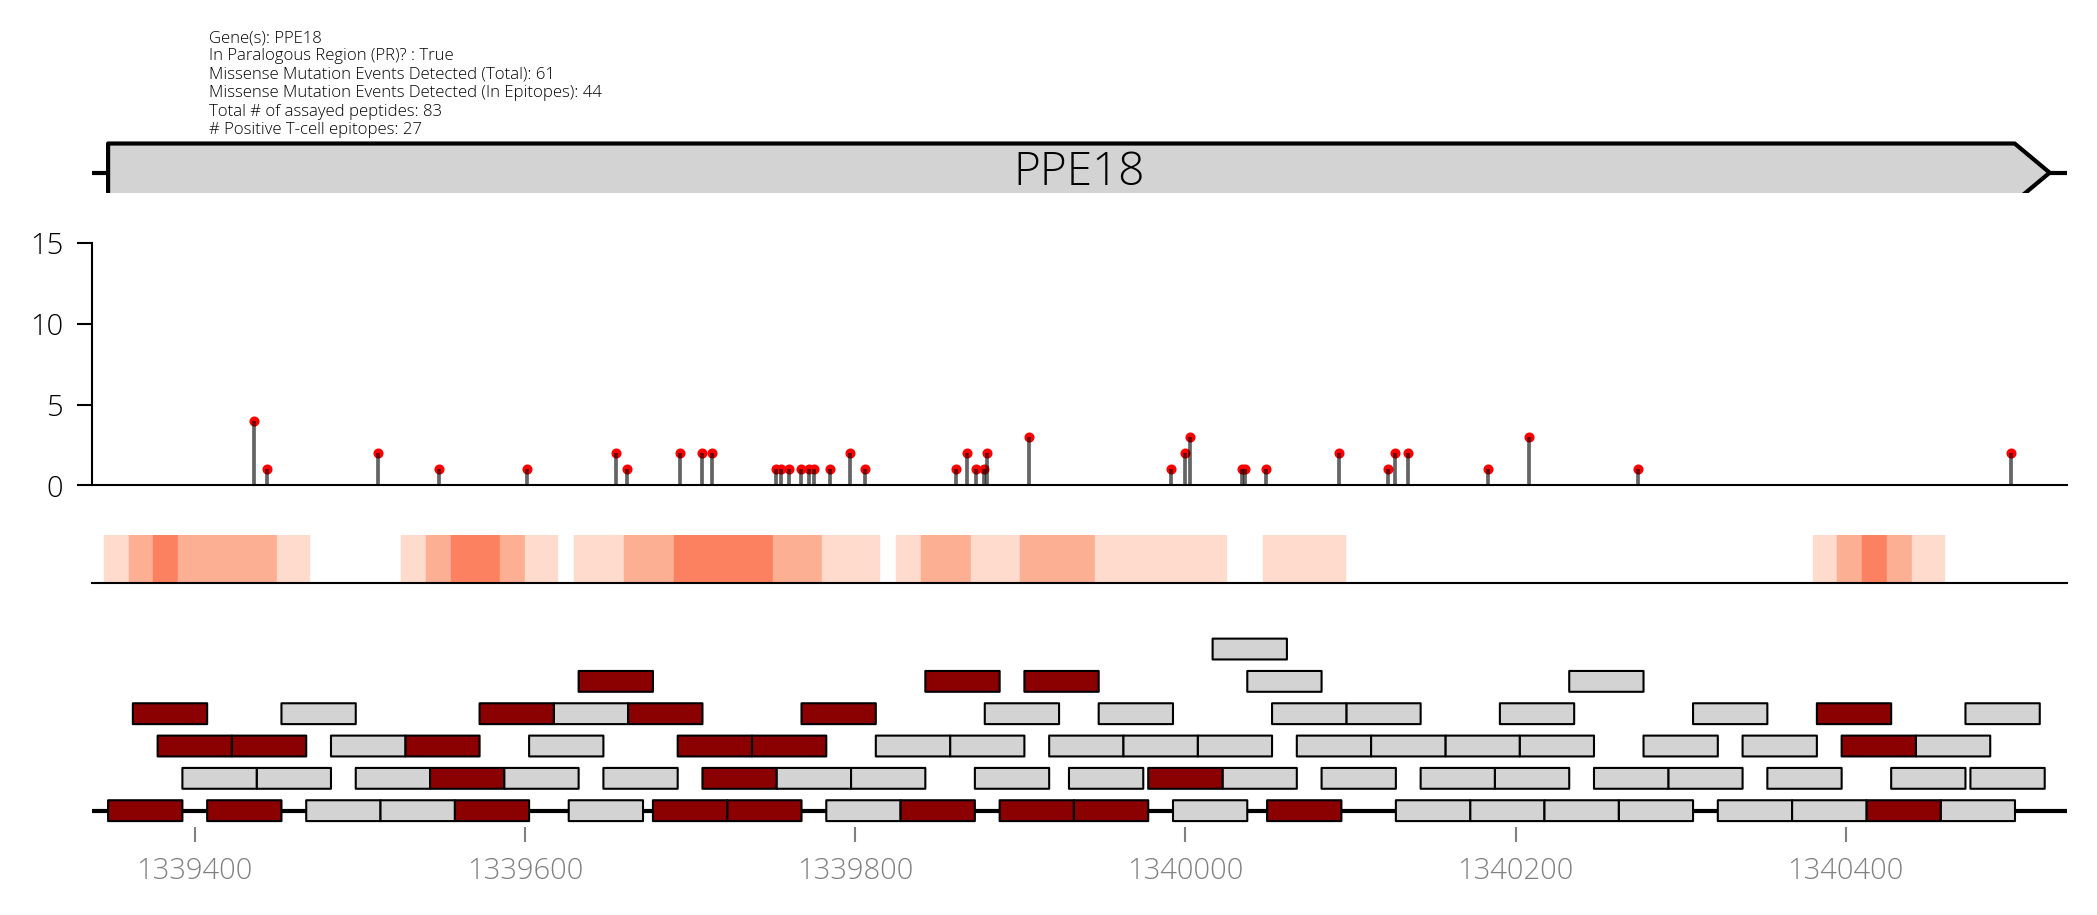

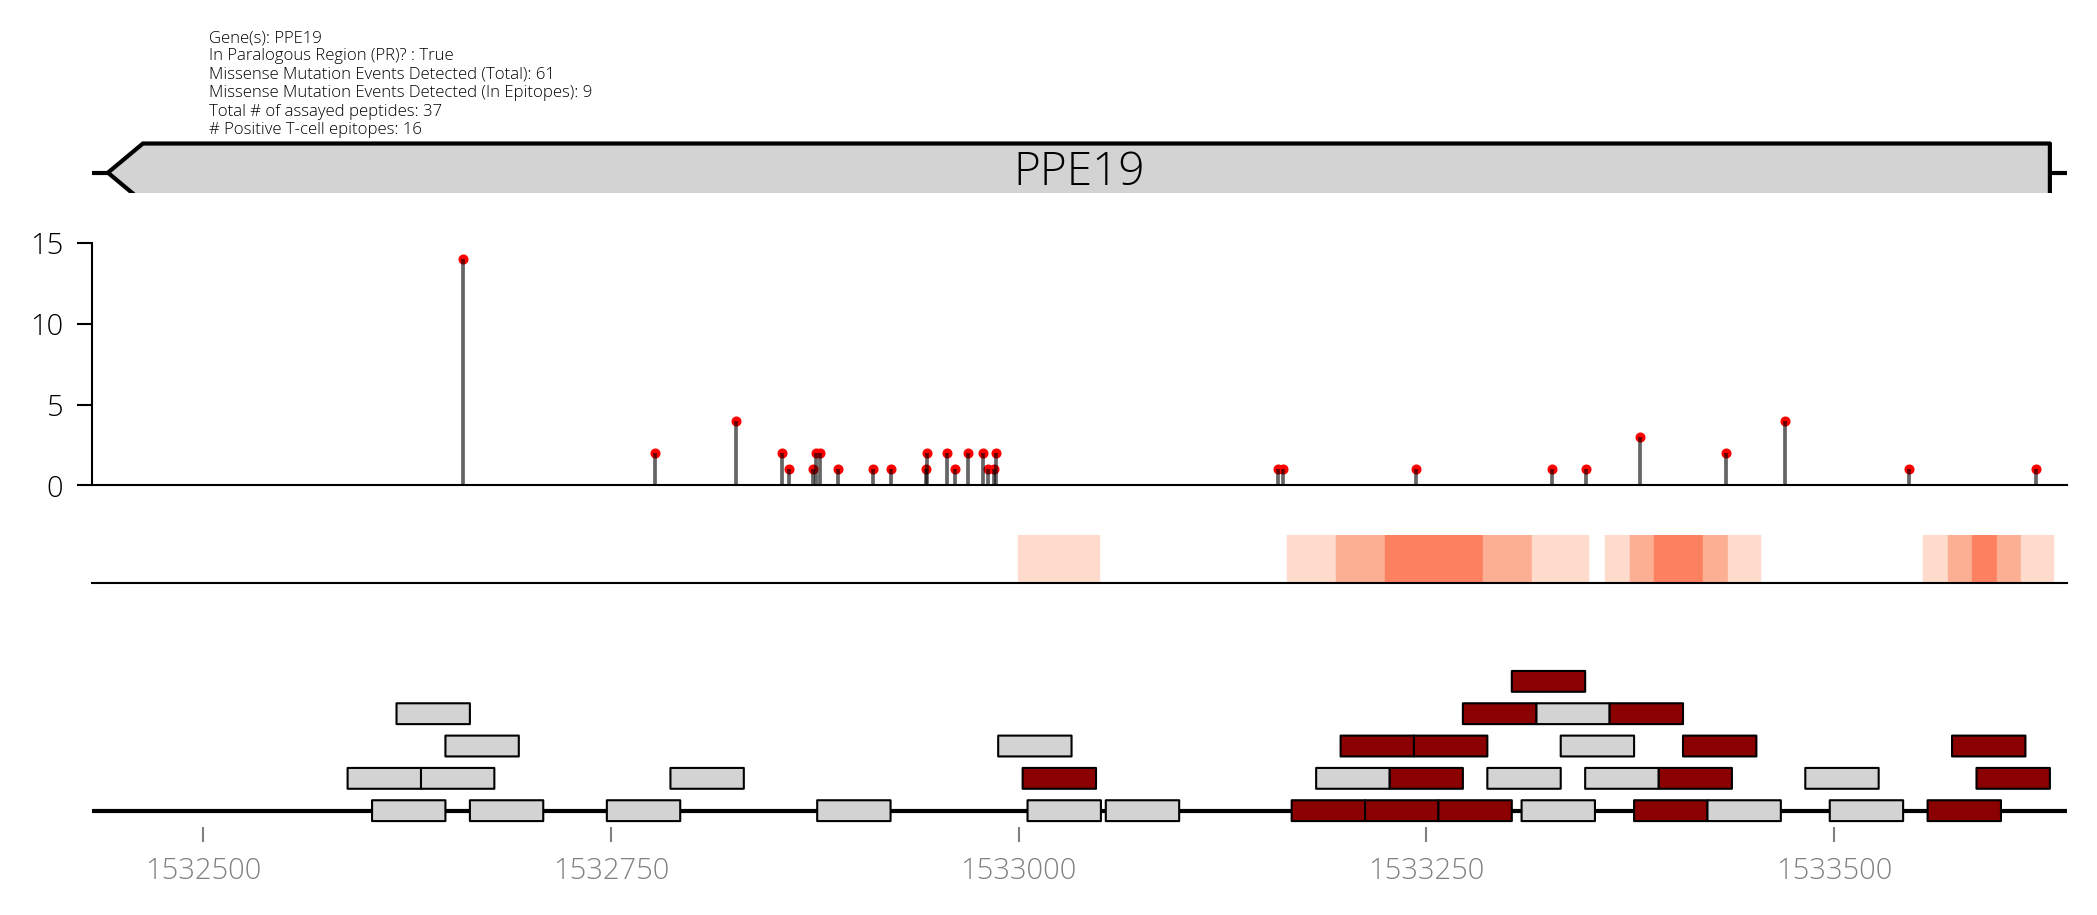

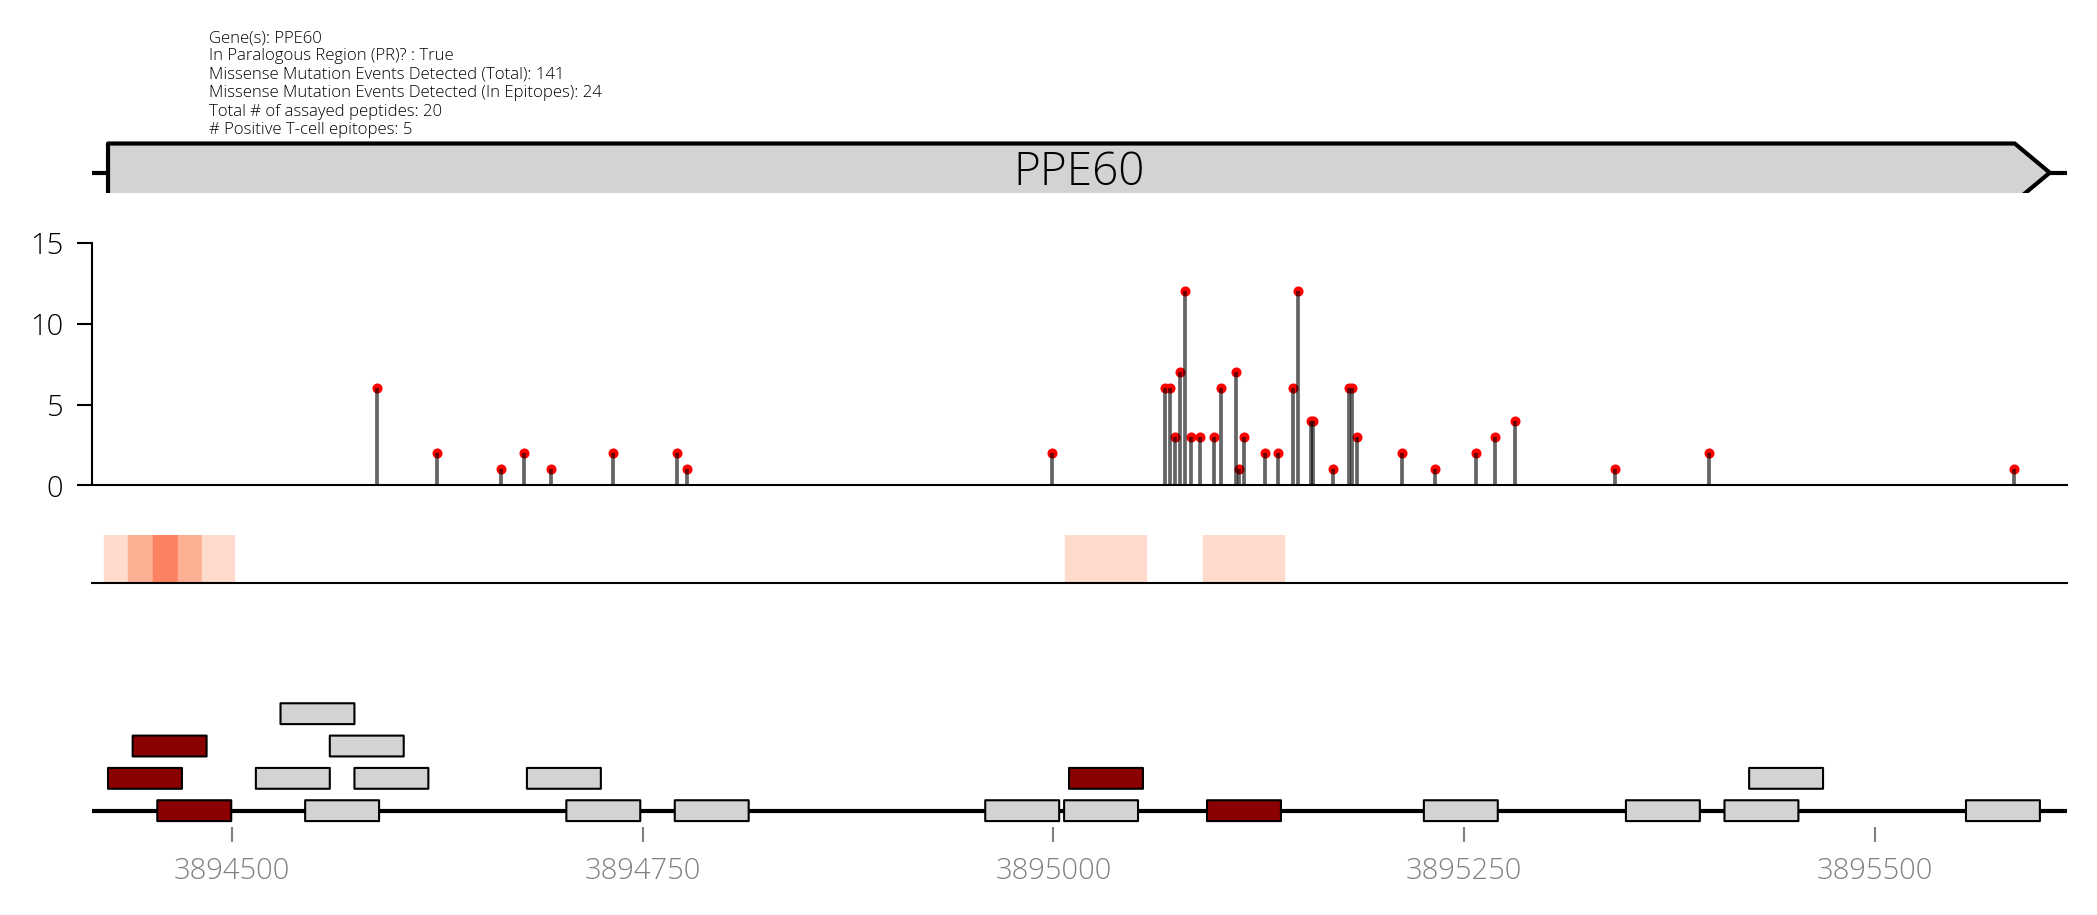

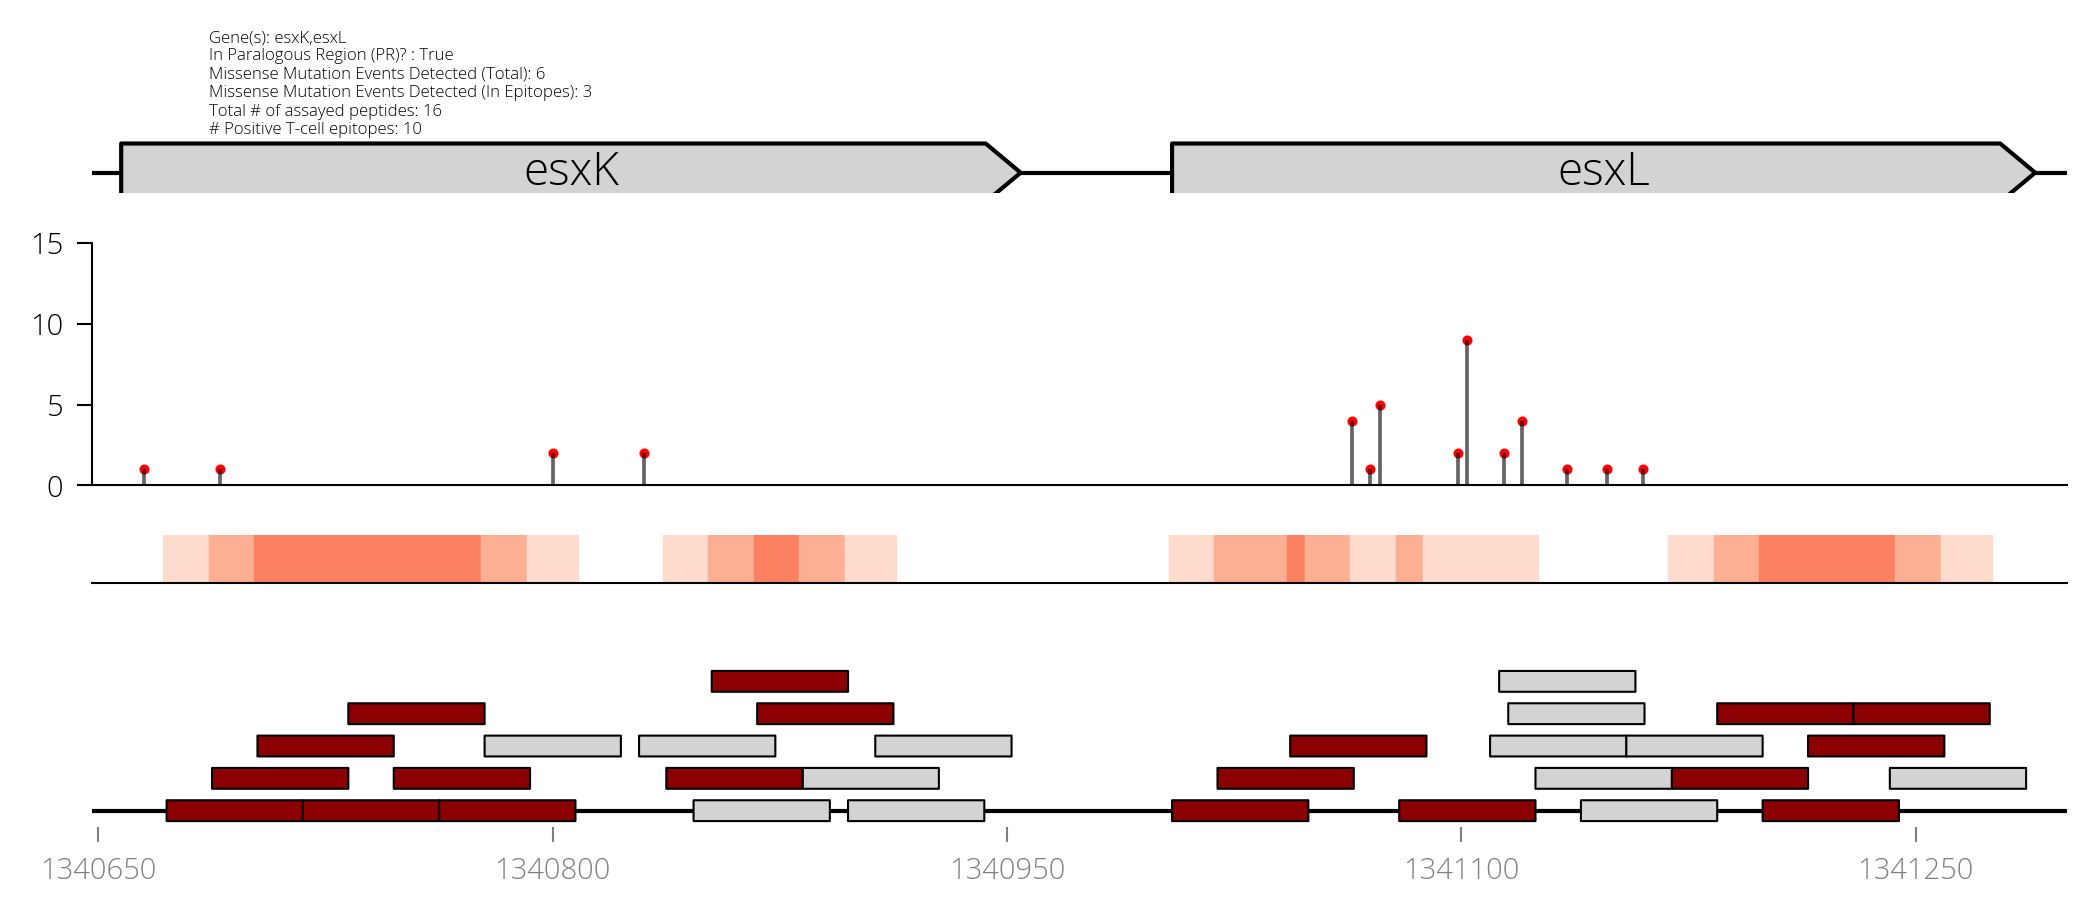

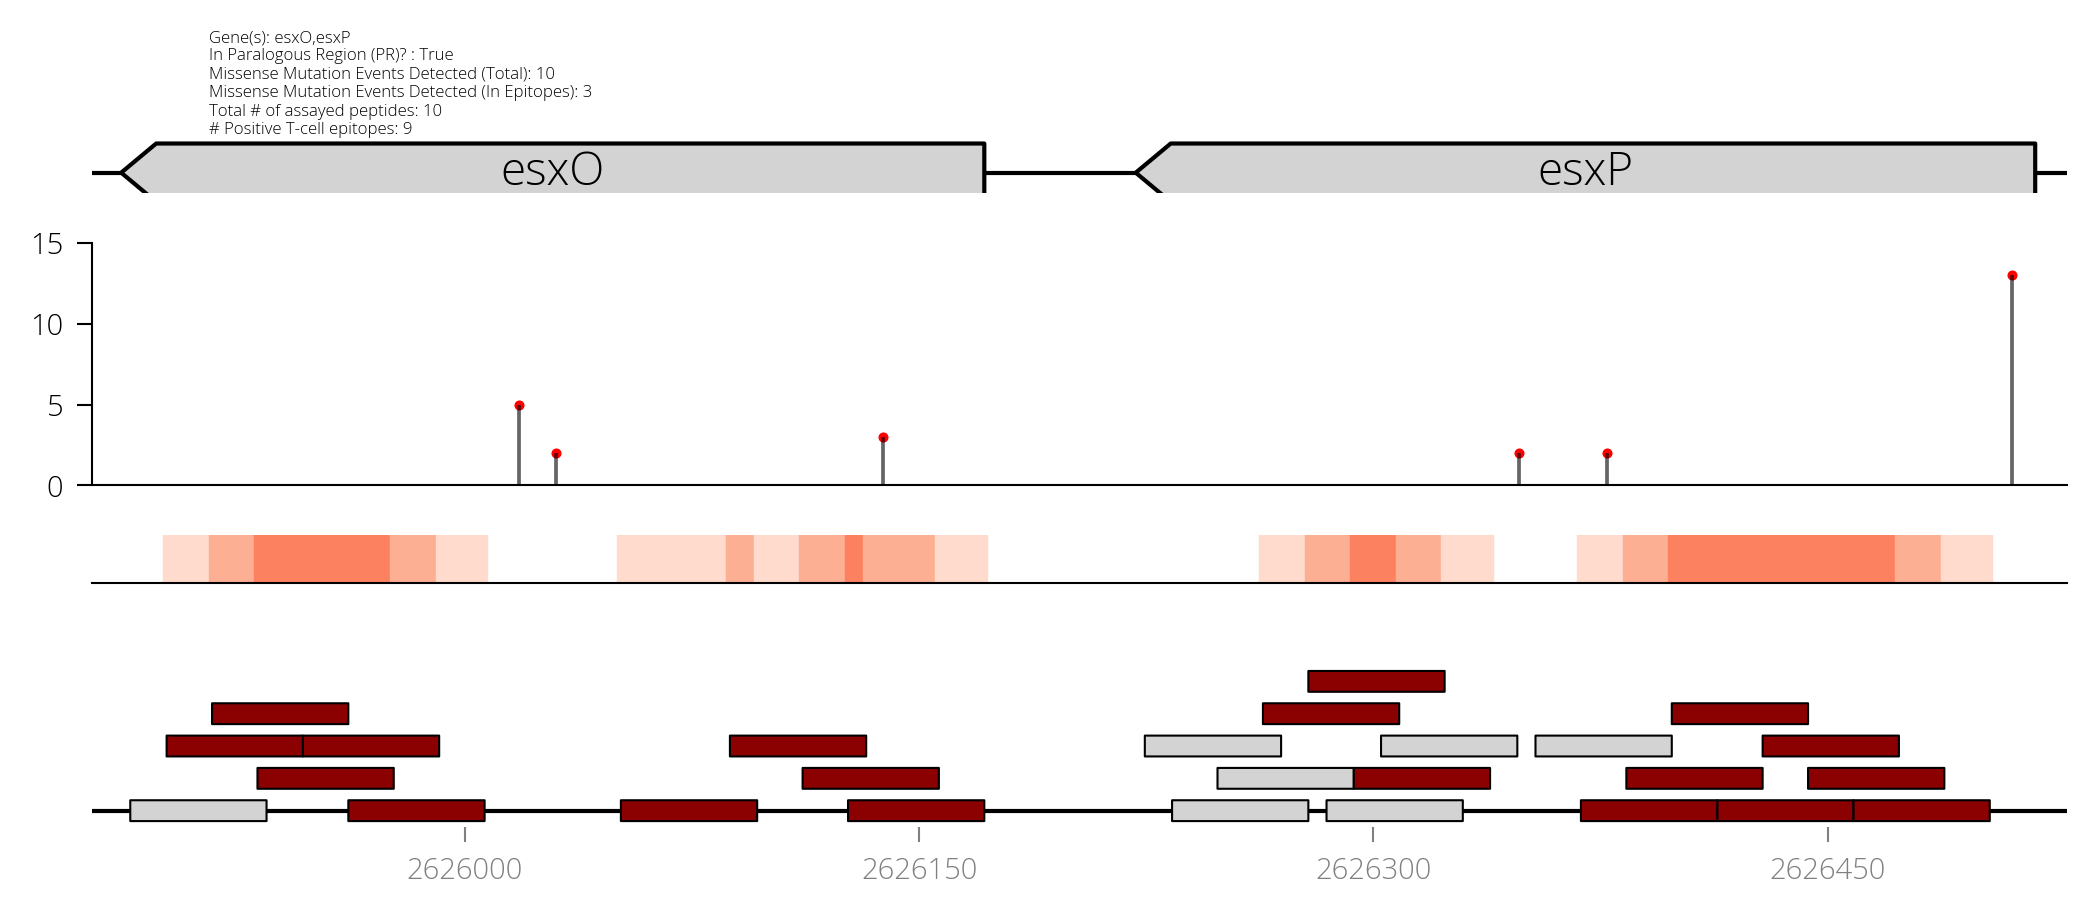

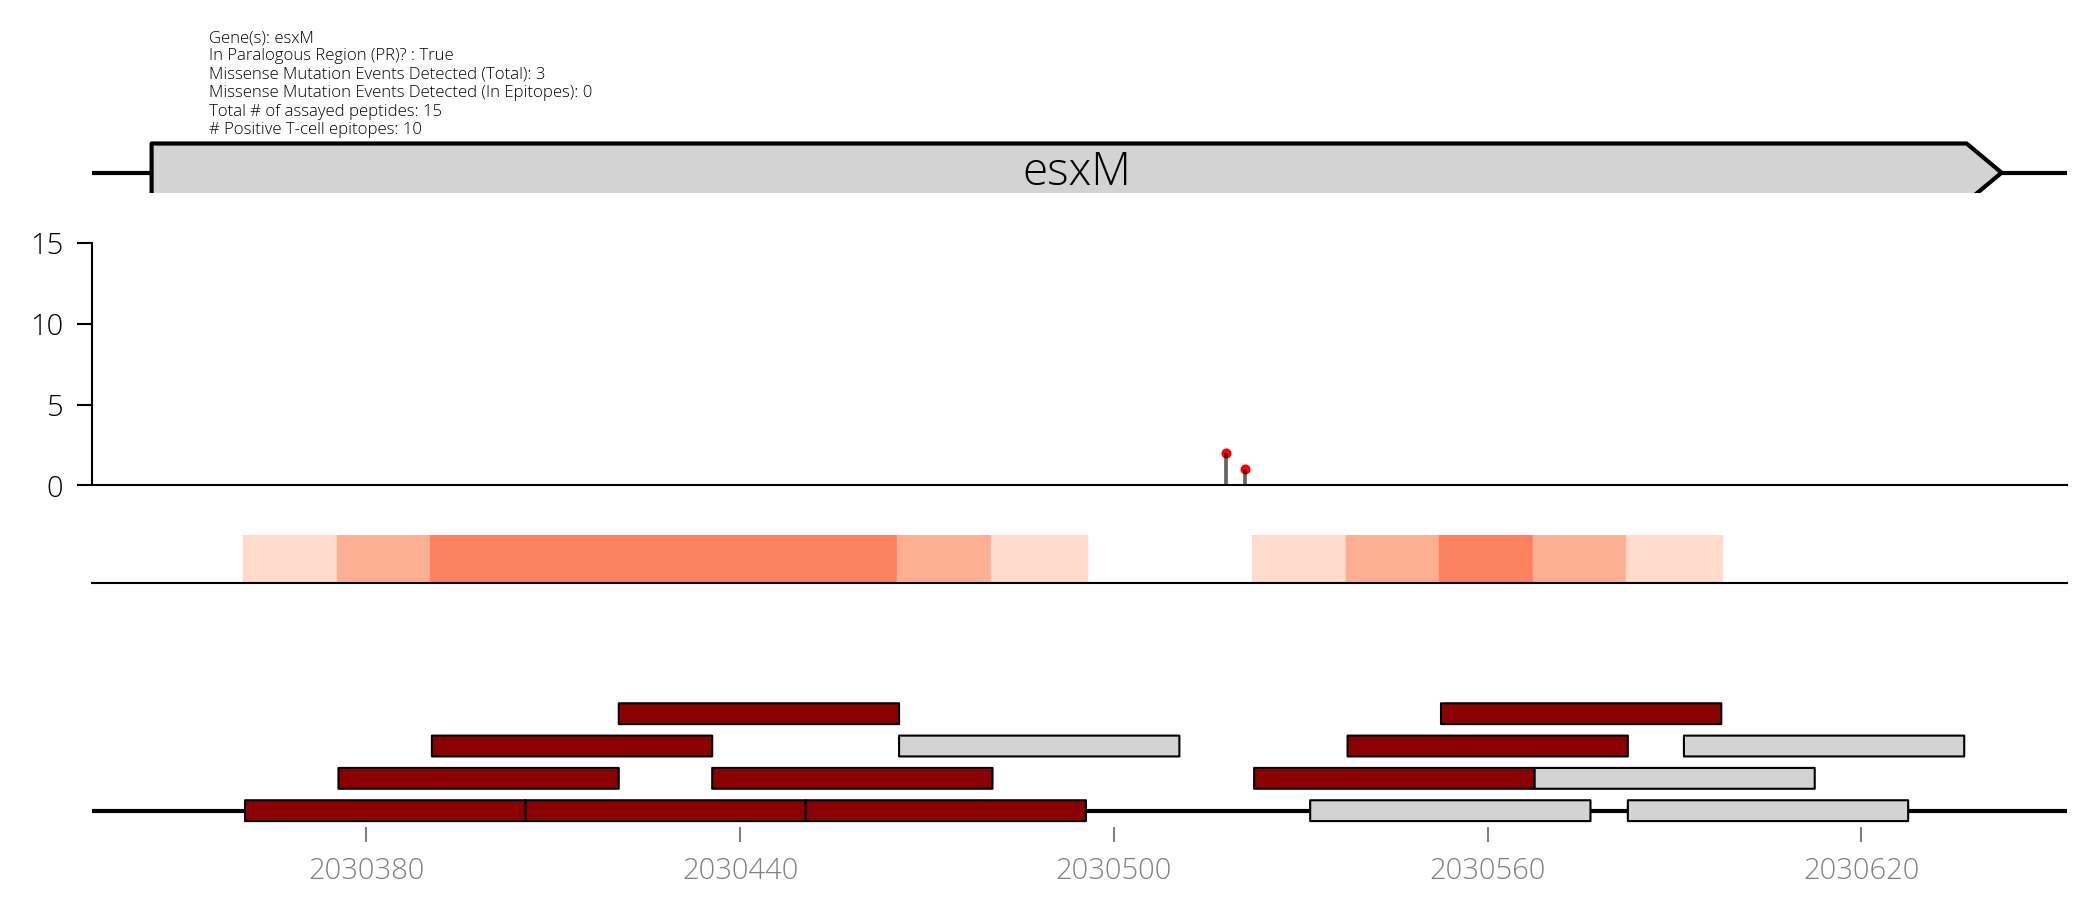

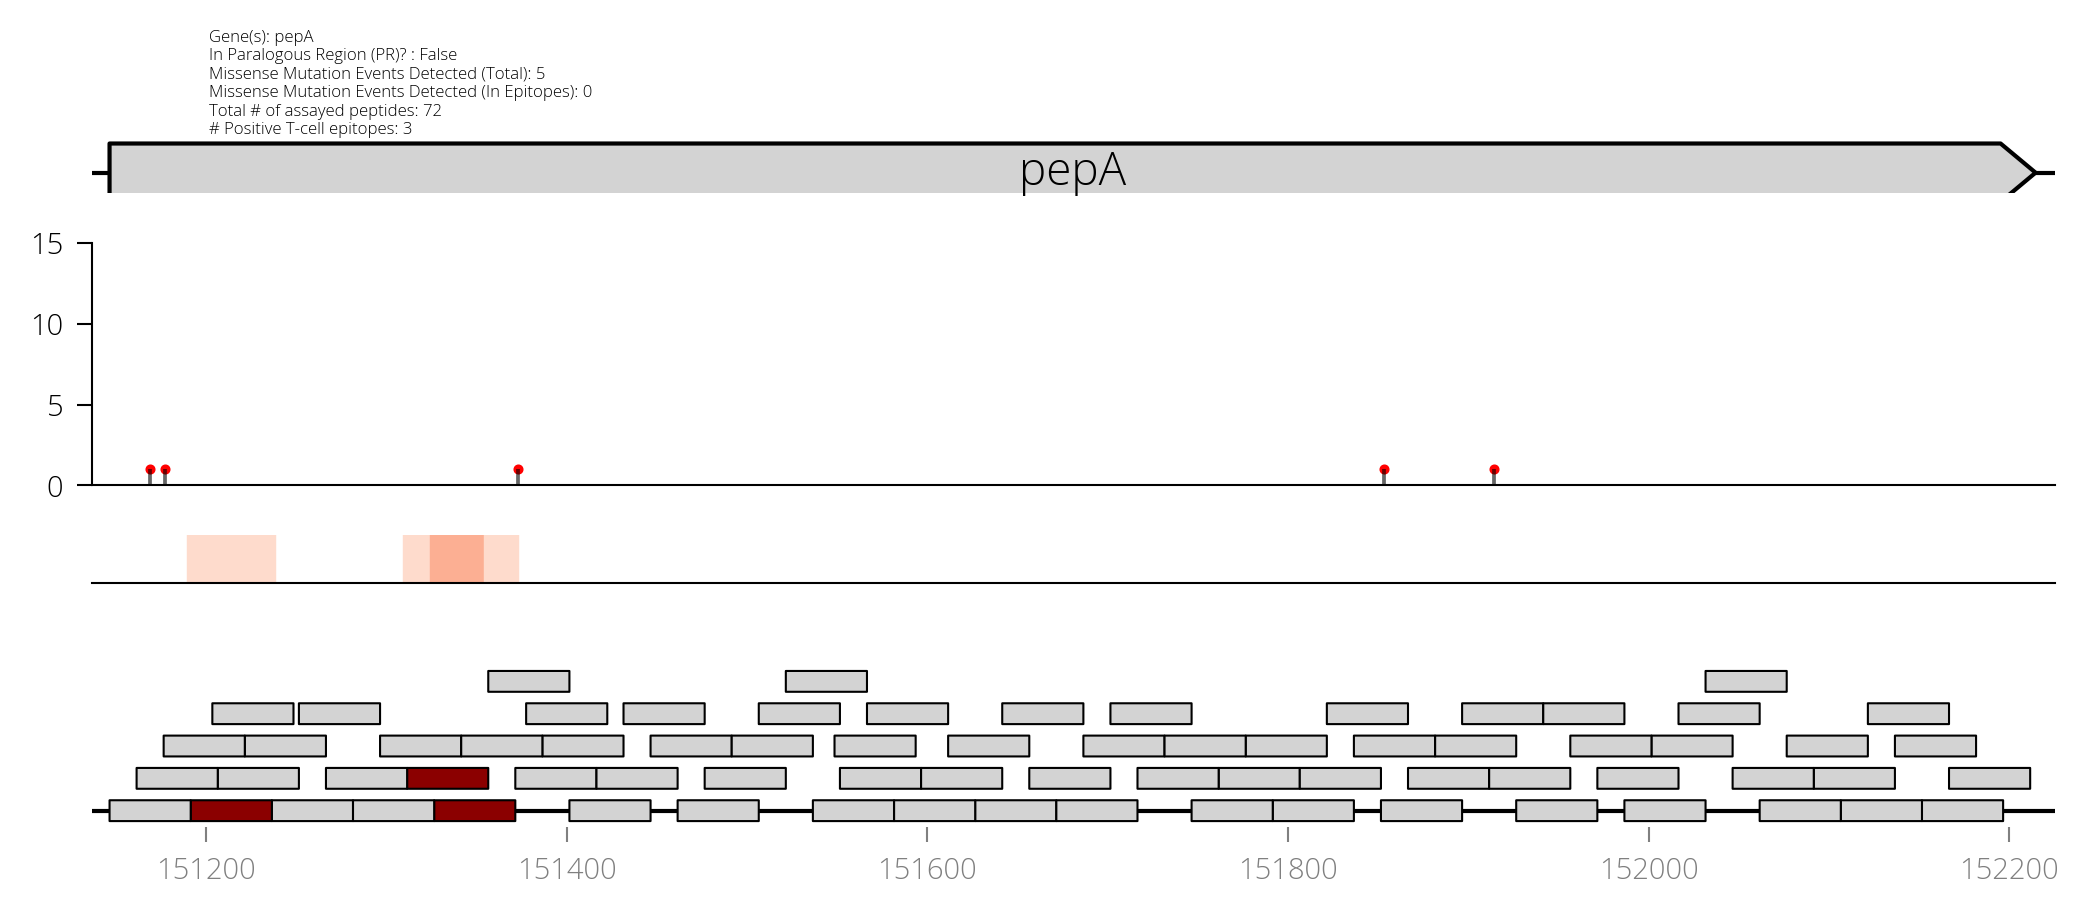

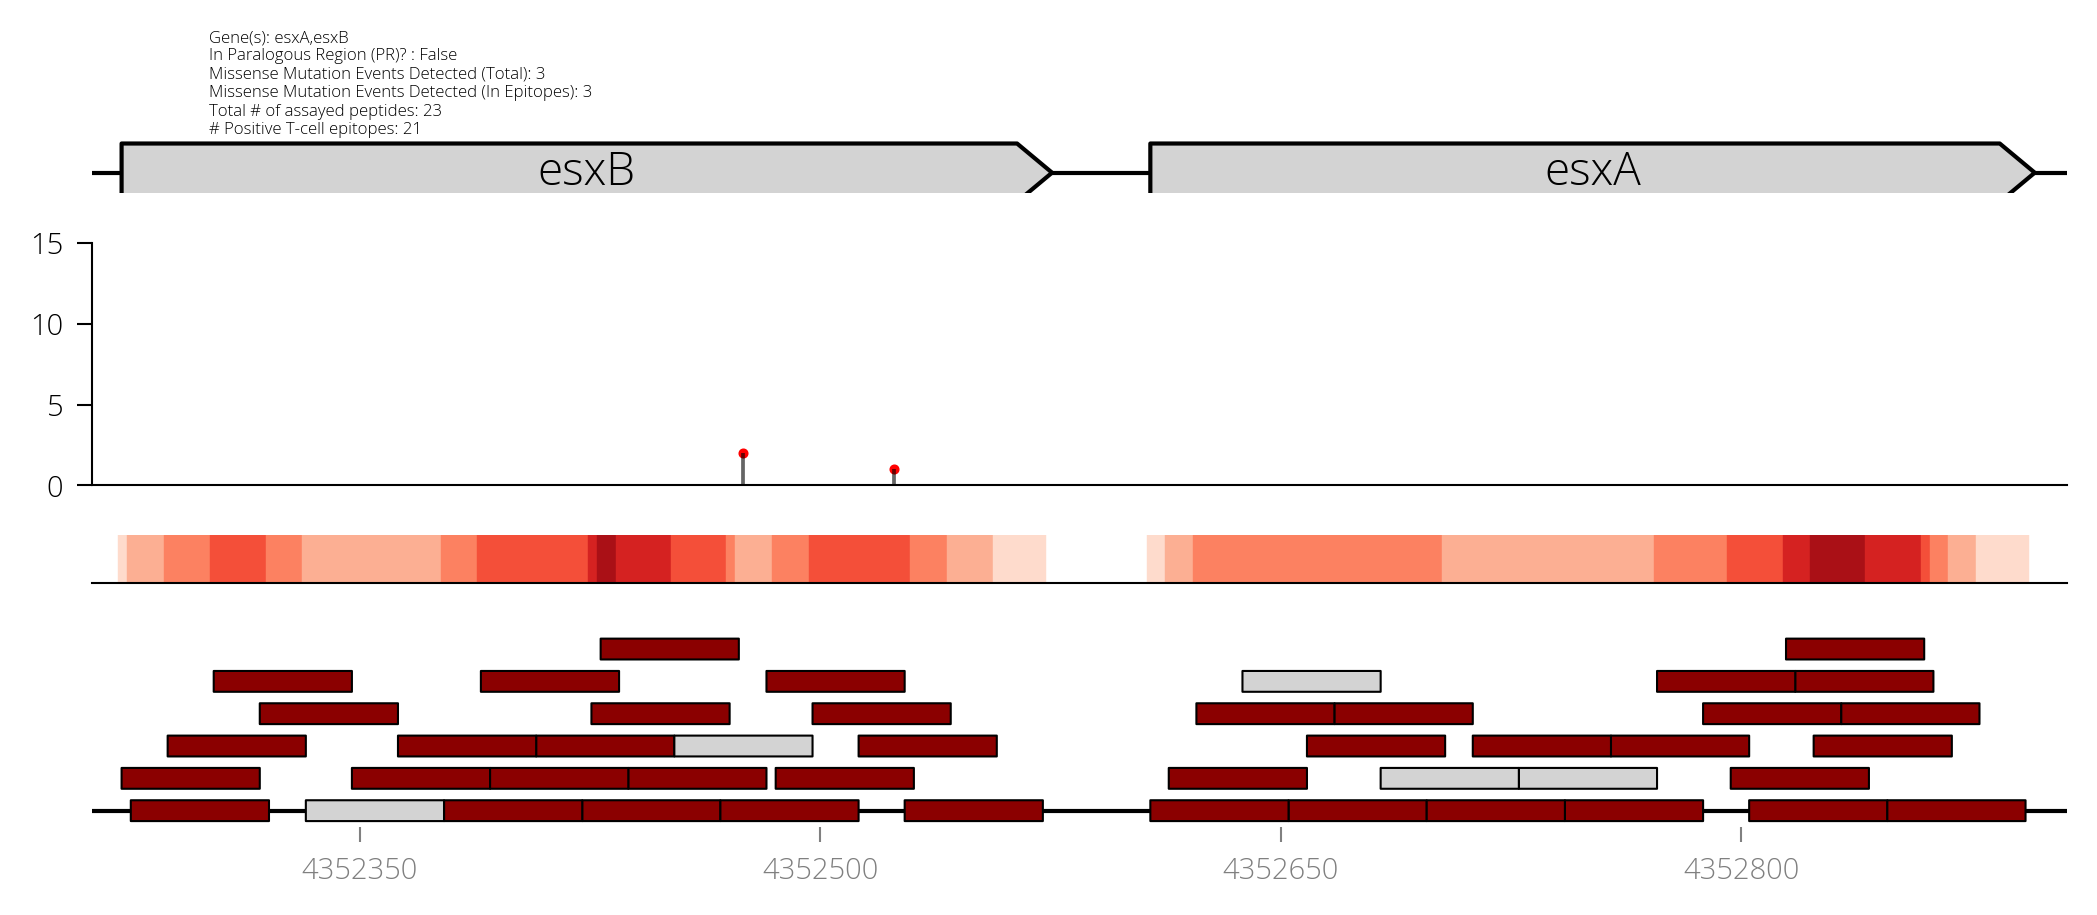

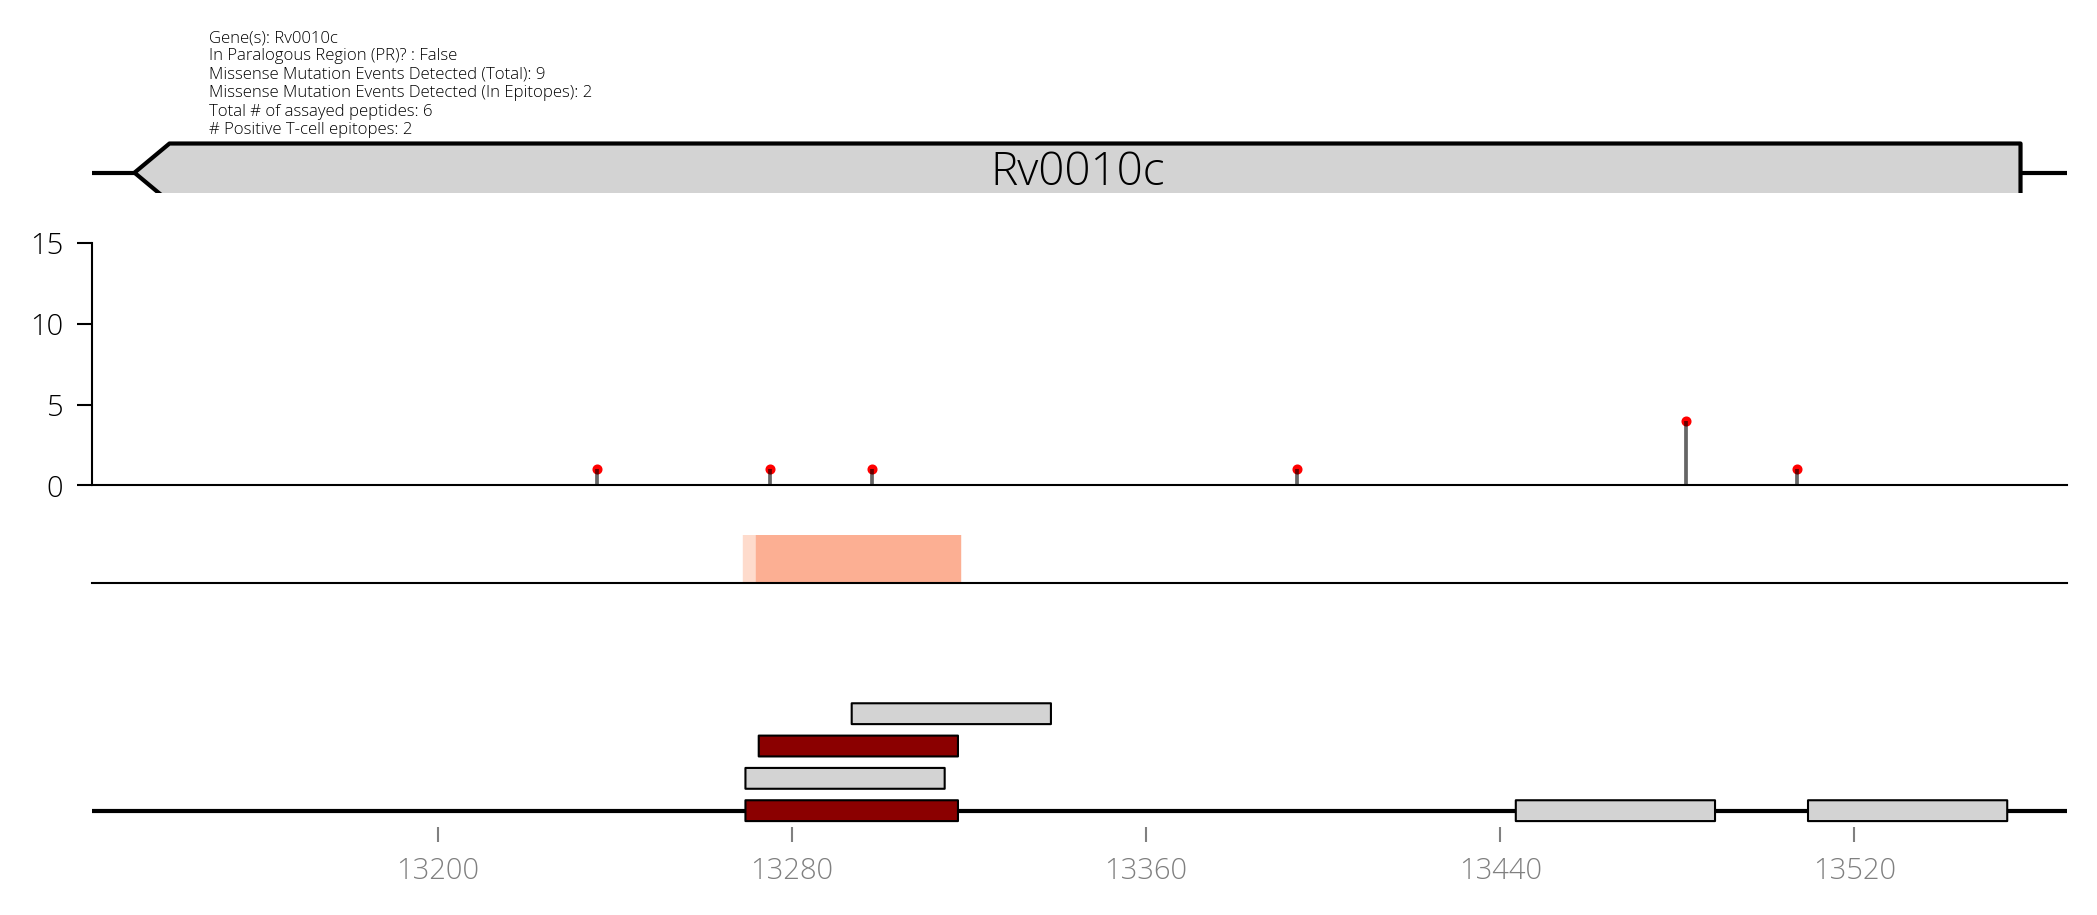

In [603]:
in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF


input_Antigen_Symbols = [ "PPE18", "PPE19", "PPE60", "esxK,esxL", "esxO,esxP",
                         "esxM", "pepA", "esxA,esxB", "Rv0010c", ]

#input_Antigen_Symbols = ["pepA", "esxA", "PPE18",]

for i_Symbol in input_Antigen_Symbols:

    i_Symbol_List = i_Symbol.split(",")
    i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

    i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
    i_Gene_End = i_Gene_MutInfo_DF["End"].max()
    Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10
    
    i_N_Mut_Total = i_Gene_MutInfo_DF["Total_NS_Muts"].values[0]
    i_N_Mut_InEpitope = i_Gene_MutInfo_DF["Total_NS_Muts_InEpitope"].values[0]

    i_Gene_N_Epitopes = i_Gene_MutInfo_DF["N_Pos"].values[0]
    i_Gene_N_NegPeptide = i_Gene_MutInfo_DF["N_Neg"].values[0]
    i_Gene_N_PeptidesAssayed = i_Gene_MutInfo_DF["Total"].values[0]

    i_Gene_InHHR = i_Gene_MutInfo_DF["HasHmRegion"].values[0]

    GeneInfo_StrList = []
    GeneInfo_StrList.append( "Gene(s): " + i_Symbol)
    GeneInfo_StrList.append( "In Paralogous Region (PR)? : " + str(i_Gene_InHHR))

    GeneInfo_StrList.append( "Missense Mutation Events Detected (Total): " + str(int(i_N_Mut_Total))   )
    GeneInfo_StrList.append( "Missense Mutation Events Detected (In Epitopes): " +  str(int(i_N_Mut_InEpitope))  )
    #GeneInfo_StrList.append("")
    GeneInfo_StrList.append( "Total # of assayed peptides: " +  str(int(i_Gene_N_PeptidesAssayed)) )
    GeneInfo_StrList.append( "# Positive T-cell epitopes: " +  str(int(i_Gene_N_Epitopes))  )
    #GeneInfo_StrList.append( "# Negative peptides (non-reactive): " +  str(int(i_Gene_N_NegPeptide))  )

    print("\n".join(GeneInfo_StrList))
    print("\n")

    i_GEM_fig, i_GEM_axes = plot_Anno_Epitope_MutFreq(Viz_Start = Viz_Start, Viz_End = Viz_End,
                                                   in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF,
                                                   in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                                   in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord,
                                                   in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF,
                                                   mut_ylim=(0, 15),)

    i_GEM_fig.text(0.1, 0.87, "\n".join(GeneInfo_StrList), fontsize=4)


    #i_GEM_fig.savefig(f"GeneViz_EpitopeAndNSMutFreq_Plots/{i_Symbol}.EpitopeAndNSMutFreq.V2.svg")
    
    i_GEM_fig.show()



# Part 2: Plot `genes` + `epitopes`  + `Mutation-Freq` -  Top `PR-Antigens`

In [604]:
pGCE_DF.shape

(324, 51)

In [605]:
Gub_SNPs_V2_DF.shape

(26508, 24)

In [606]:
Genes_GCandMutFreqStats_DF.head(3)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq,0,0,10.0,0.0,0.0,0.0,0.0,10.0,1.968504,0.0,False,False,False,False,False,True
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq,0,0,2.0,0.0,0.0,0.0,0.0,2.0,0.496278,0.0,False,False,False,False,False,True
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq,0,0,7.0,0.0,0.0,0.0,0.0,7.0,1.813472,0.0,False,False,False,False,False,True


# Curate list of all antigens to plot data for

In [607]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
9,NC_000962.3,13132,13558,-,CDS,Rv0010c,Rv0010c,cell wall and cell processes,cell wall and cell processes,2,4,6,0.333333,13345.0,426,True,True,0,False,Antigen-Unq,0,0,9.0,2.0,0.0,0.0,0.0,9.0,6.338028,1.408451,False,False,False,False,False,True
123,NC_000962.3,151147,152215,+,CDS,Rv0125,pepA,intermediary metabolism and respiration,intermediary metabolism and respiration,3,69,72,0.041667,151681.0,1068,True,True,0,False,Antigen-Unq,0,0,5.0,0.0,0.0,0.0,0.0,5.0,1.404494,0.000000,False,False,False,False,False,True
174,NC_000962.3,207451,208420,+,CDS,Rv0176,Rv0176,cell wall and cell processes,cell wall and cell processes,2,3,5,0.400000,207935.5,969,True,True,0,False,Antigen-Unq,0,0,6.0,0.0,0.0,0.0,0.0,6.0,1.857585,0.000000,False,False,False,False,False,True
274,NC_000962.3,331747,332668,+,CDS,Rv0276,Rv0276,conserved hypotheticals,conserved hypotheticals,3,2,5,0.600000,332207.5,921,True,True,0,False,Antigen-Unq,0,0,3.0,1.0,0.0,0.0,0.0,3.0,0.977199,0.325733,False,False,False,False,False,True
282,NC_000962.3,345634,349627,+,CDS,Rv0284,eccC3,cell wall and cell processes,cell wall and cell processes,6,4,10,0.600000,347630.5,3993,True,True,0,False,Antigen-Unq,0,0,7.0,1.0,0.0,0.0,0.0,7.0,0.525920,0.075131,False,False,False,False,False,True


In [608]:
Antigen_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
Antigen-Unq    33
Antigen-HHR    20
Name: count, dtype: int64

In [609]:
input_PR_Antigen_Symbols_WiPairs = ["PPE18", "PPE19", "PPE60",
                                     "esxL,esxK", "esxO,esxP", "esxM,esxN",
                                     "esxI,esxJ", "esxV,esxW",
                                     "PPE46", "Rv1199c", "Rv3115", "Rv2512c", "Rv3023c", "Rv1047", "PE13"]

In [610]:
len(input_Antigen_Symbols)

9

In [611]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR' ").sort_values("RelFreq_NS_Muts", ascending = False)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
3397,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True
1174,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True
2295,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True
1172,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True
1337,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True
2294,NC_000962.3,2625887,2626172,-,CDS,Rv2346c,esxO,cell wall and cell processes,esx,9,1,10,0.900000,2626029.5,285,True,True,1,True,Antigen-HHR,5,5,10.0,3.0,6.0,6.0,6.0,10.0,10.526316,3.157895,True,True,True,True,True,True
1760,NC_000962.3,2030693,2030978,+,CDS,Rv1793,esxN,cell wall and cell processes,esx,8,2,10,0.800000,2030835.5,285,True,True,1,True,Antigen-HHR,3,3,8.0,1.0,7.0,7.0,7.0,8.0,8.421053,1.052632,True,True,True,True,True,True
1173,NC_000962.3,1340658,1340955,+,CDS,Rv1197,esxK,cell wall and cell processes,esx,10,6,16,0.625000,1340806.5,297,True,True,1,True,Antigen-HHR,5,3,6.0,3.0,1.0,3.0,1.0,6.0,6.060606,3.030303,True,True,True,True,True,True
3051,NC_000962.3,3481450,3482698,+,CDS,Rv3115,Rv3115,insertion seqs and phages,insertion seqs and phages,3,5,8,0.375000,3482074.0,1248,True,True,1,True,Antigen-HHR,0,0,20.0,1.0,0.0,0.0,0.0,20.0,4.807692,0.240385,False,False,False,False,False,True
2955,NC_000962.3,3376938,3378243,-,CDS,Rv3018c,PPE46,PE/PPE,PE/PPE,3,3,6,0.500000,3377590.5,1305,True,True,1,True,Antigen-HHR,2,0,18.0,0.0,0.0,11.0,0.0,18.0,4.137931,0.000000,False,False,False,True,True,True


In [612]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-Unq' ").sort_values("RelFreq_NS_Muts", ascending = False)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
9,NC_000962.3,13132,13558,-,CDS,Rv0010c,Rv0010c,cell wall and cell processes,cell wall and cell processes,2,4,6,0.333333,13345.0,426,True,True,0,False,Antigen-Unq,0,0,9.0,2.0,0.0,0.0,0.0,9.0,6.338028,1.408451,False,False,False,False,False,True
286,NC_000962.3,351847,352138,+,CDS,Rv0288,esxH,cell wall and cell processes,esx,23,3,26,0.884615,351992.5,291,True,True,0,False,Antigen-Unq,0,0,3.0,3.0,0.0,0.0,0.0,3.0,3.092784,3.092784,False,False,False,False,False,True
3790,NC_000962.3,4352273,4352576,+,CDS,Rv3874,esxB,cell wall and cell processes,esx,21,2,23,0.913043,4352424.5,303,True,True,0,False,Antigen-Unq,0,0,3.0,3.0,0.0,0.0,0.0,3.0,2.970297,2.970297,False,False,False,False,False,True
2601,NC_000962.3,2980962,2981190,-,CDS,Rv2660c,Rv2660c,conserved hypotheticals,conserved hypotheticals,2,12,14,0.142857,2981076.0,228,True,True,0,False,Antigen-Unq,0,0,2.0,1.0,0.0,0.0,0.0,2.0,2.631579,1.315789,False,False,False,False,False,True
983,NC_000962.3,1111611,1112223,+,CDS,Rv0995,rimJ,information pathways,information pathways,2,3,5,0.400000,1111917.0,612,True,True,0,False,Antigen-Unq,0,0,5.0,1.0,0.0,0.0,0.0,5.0,2.450980,0.490196,False,False,False,False,False,True
1755,NC_000962.3,2026476,2026776,+,CDS,Rv1788,PE18,PE/PPE,PE/PPE,2,1,3,0.666667,2026626.0,300,True,True,0,False,Antigen-Unq,0,0,2.0,1.0,0.0,0.0,0.0,2.0,2.000000,1.000000,False,False,False,False,False,True
174,NC_000962.3,207451,208420,+,CDS,Rv0176,Rv0176,cell wall and cell processes,cell wall and cell processes,2,3,5,0.400000,207935.5,969,True,True,0,False,Antigen-Unq,0,0,6.0,0.0,0.0,0.0,0.0,6.0,1.857585,0.000000,False,False,False,False,False,True
3061,NC_000962.3,3490475,3491651,-,CDS,Rv3125c,PPE49,PE/PPE,PE/PPE,2,4,6,0.333333,3491063.0,1176,True,True,0,False,Antigen-Unq,0,0,6.0,0.0,0.0,0.0,0.0,6.0,1.530612,0.000000,False,False,False,False,False,True
1769,NC_000962.3,2043383,2044775,+,CDS,Rv1802,PPE30,PE/PPE,PE/PPE,2,5,7,0.285714,2044079.0,1392,True,True,0,False,Antigen-Unq,0,0,7.0,0.0,0.0,0.0,0.0,7.0,1.508621,0.000000,False,False,False,False,False,True
123,NC_000962.3,151147,152215,+,CDS,Rv0125,pepA,intermediary metabolism and respiration,intermediary metabolism and respiration,3,69,72,0.041667,151681.0,1068,True,True,0,False,Antigen-Unq,0,0,5.0,0.0,0.0,0.0,0.0,5.0,1.404494,0.000000,False,False,False,False,False,True


# Make plots - `Gene-Epitopes-Mutations-GCEs` plots for top HHR Antigens

In [613]:
Genes_GCandMutFreqStats_DF.head(4)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq,0,0,10.0,0.0,0.0,0.0,0.0,10.0,1.968504,0.0,False,False,False,False,False,True
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq,0,0,2.0,0.0,0.0,0.0,0.0,2.0,0.496278,0.0,False,False,False,False,False,True
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq,0,0,7.0,0.0,0.0,0.0,0.0,7.0,1.813472,0.0,False,False,False,False,False,True
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq,0,0,5.0,0.0,0.0,0.0,0.0,5.0,2.659574,0.0,False,False,False,False,False,True


In [614]:
!mkdir ./PerGeneViz_Epitopes_MutFreq_GCEs_Plots/

mkdir: cannot create directory ‘./PerGeneViz_Epitopes_MutFreq_GCEs_Plots/’: File exists


Gene(s): PPE18
In Paralogous Region (PR)? : [ True]
# of Gene Conversion Events (GCE) detected: 8
Missense Mutation Events Detected (Total): 61
Missense Mutation Events Detected (In Epitopes): 44
Total # of assayed peptides: 83
# Positive T-cell epitopes: 27




/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1426: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if "Pos_0based" in snps.columns:
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1427: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snps["__pos1__"] = snps["Pos_0based"].astype(int) + 1
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1428: SettingWithCopyWarning: 
A 

Gene(s): PPE19
In Paralogous Region (PR)? : [ True]
# of Gene Conversion Events (GCE) detected: 5
Missense Mutation Events Detected (Total): 61
Missense Mutation Events Detected (In Epitopes): 9
Total # of assayed peptides: 37
# Positive T-cell epitopes: 16




/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1426: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if "Pos_0based" in snps.columns:
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1427: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snps["__pos1__"] = snps["Pos_0based"].astype(int) + 1
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1428: SettingWithCopyWarning: 
A 

Gene(s): PPE60
In Paralogous Region (PR)? : [ True]
# of Gene Conversion Events (GCE) detected: 8
Missense Mutation Events Detected (Total): 141
Missense Mutation Events Detected (In Epitopes): 24
Total # of assayed peptides: 20
# Positive T-cell epitopes: 5




...

Gene(s): esxO,esxP
In Paralogous Region (PR)? : [ True  True]
# of Gene Conversion Events (GCE) detected: 14
Missense Mutation Events Detected (Total): 27
Missense Mutation Events Detected (In Epitopes): 5
Total # of assayed peptides: 26
# Positive T-cell epitopes: 19




/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1426: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if "Pos_0based" in snps.columns:
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1427: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snps["__pos1__"] = snps["Pos_0based"].astype(int) + 1
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1428: SettingWithCopyWarning: 
A 

Gene(s): esxM,esxN
In Paralogous Region (PR)? : [ True  True]
# of Gene Conversion Events (GCE) detected: 6
Missense Mutation Events Detected (Total): 11
Missense Mutation Events Detected (In Epitopes): 1
Total # of assayed peptides: 25
# Positive T-cell epitopes: 18




/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1426: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if "Pos_0based" in snps.columns:
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1427: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snps["__pos1__"] = snps["Pos_0based"].astype(int) + 1
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1428: SettingWithCopyWarning: 
A 

Gene(s): pepA
In Paralogous Region (PR)? : [False]
# of Gene Conversion Events (GCE) detected: 0
Missense Mutation Events Detected (Total): 5
Missense Mutation Events Detected (In Epitopes): 0
Total # of assayed peptides: 72
# Positive T-cell epitopes: 3


No events overlap the requested region.
Gene(s): esxA,esxB
In Paralogous Region (PR)? : [False False]
# of Gene Conversion Events (GCE) detected: 0
Missense Mutation Events Detected (Total): 3
Missense Mutation Events Detected (In Epitopes): 3
Total # of assayed peptides: 45
# Positive T-cell epitopes: 40


No events overlap the requested region.
Gene(s): Rv0010c
In Paralogous Region (PR)? : [False]
# of Gene Conversion Events (GCE) detected: 0
Missense Mutation Events Detected (Total): 9
Missense Mutation Events Detected (In Epitopes): 2
Total # of assayed peptides: 6
# Positive T-cell epitopes: 2


No events overlap the requested region.
Gene(s): fbpA
In Paralogous Region (PR)? : [False]
# of Gene Conversion Events (GCE) detected: 

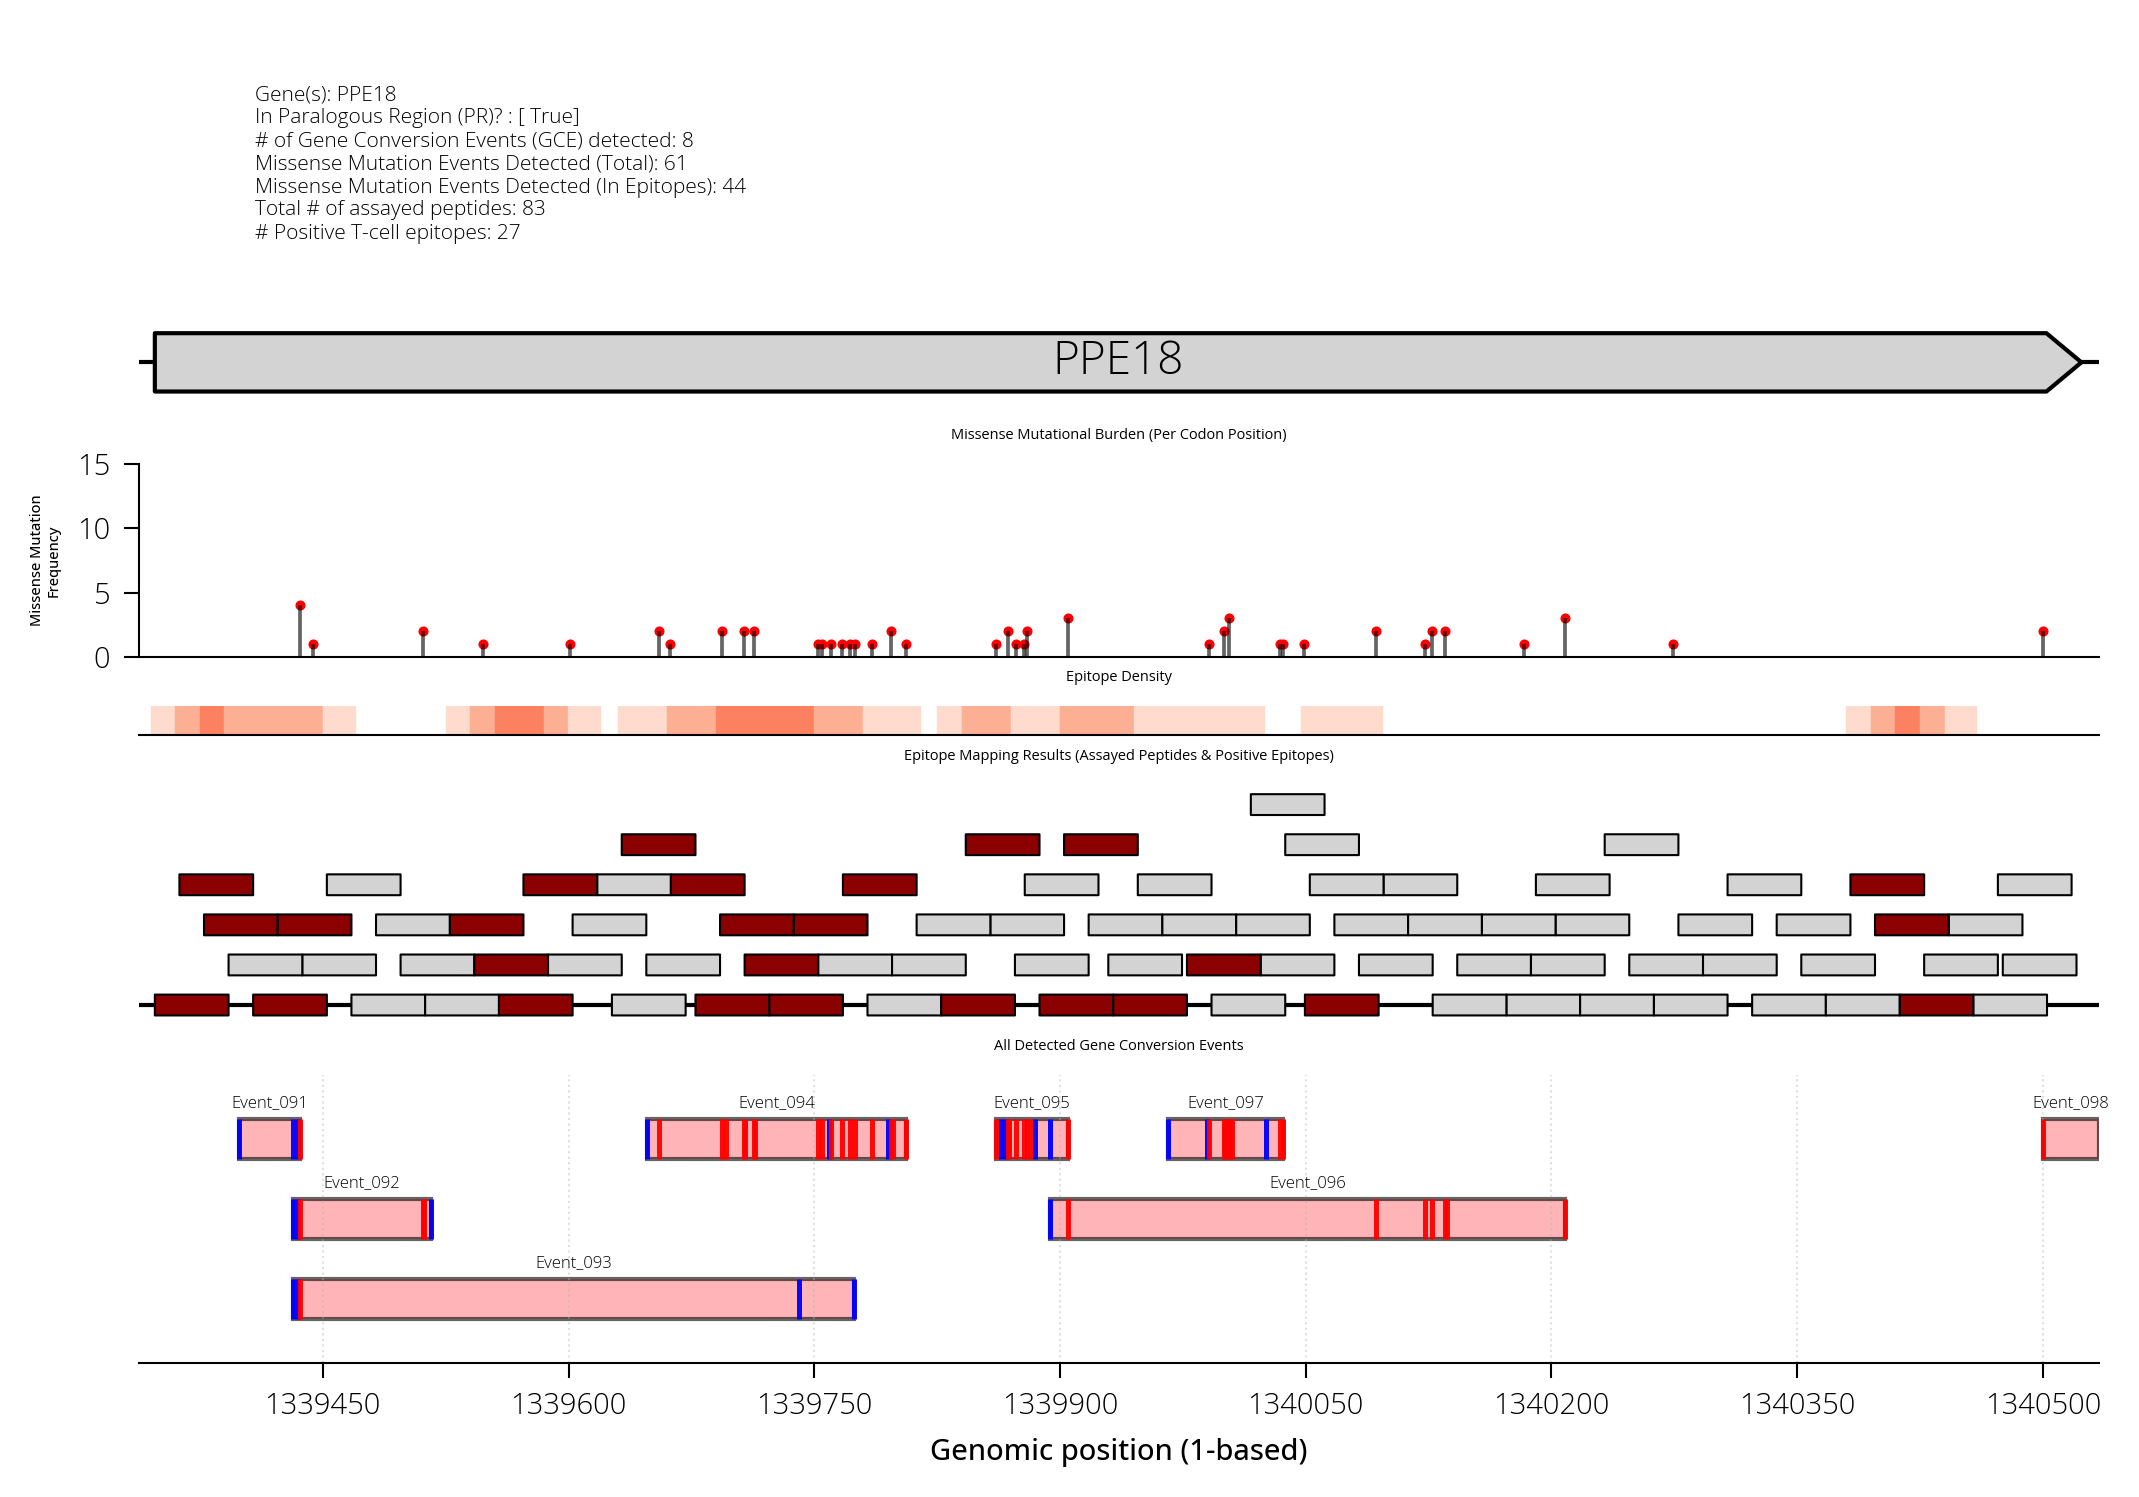

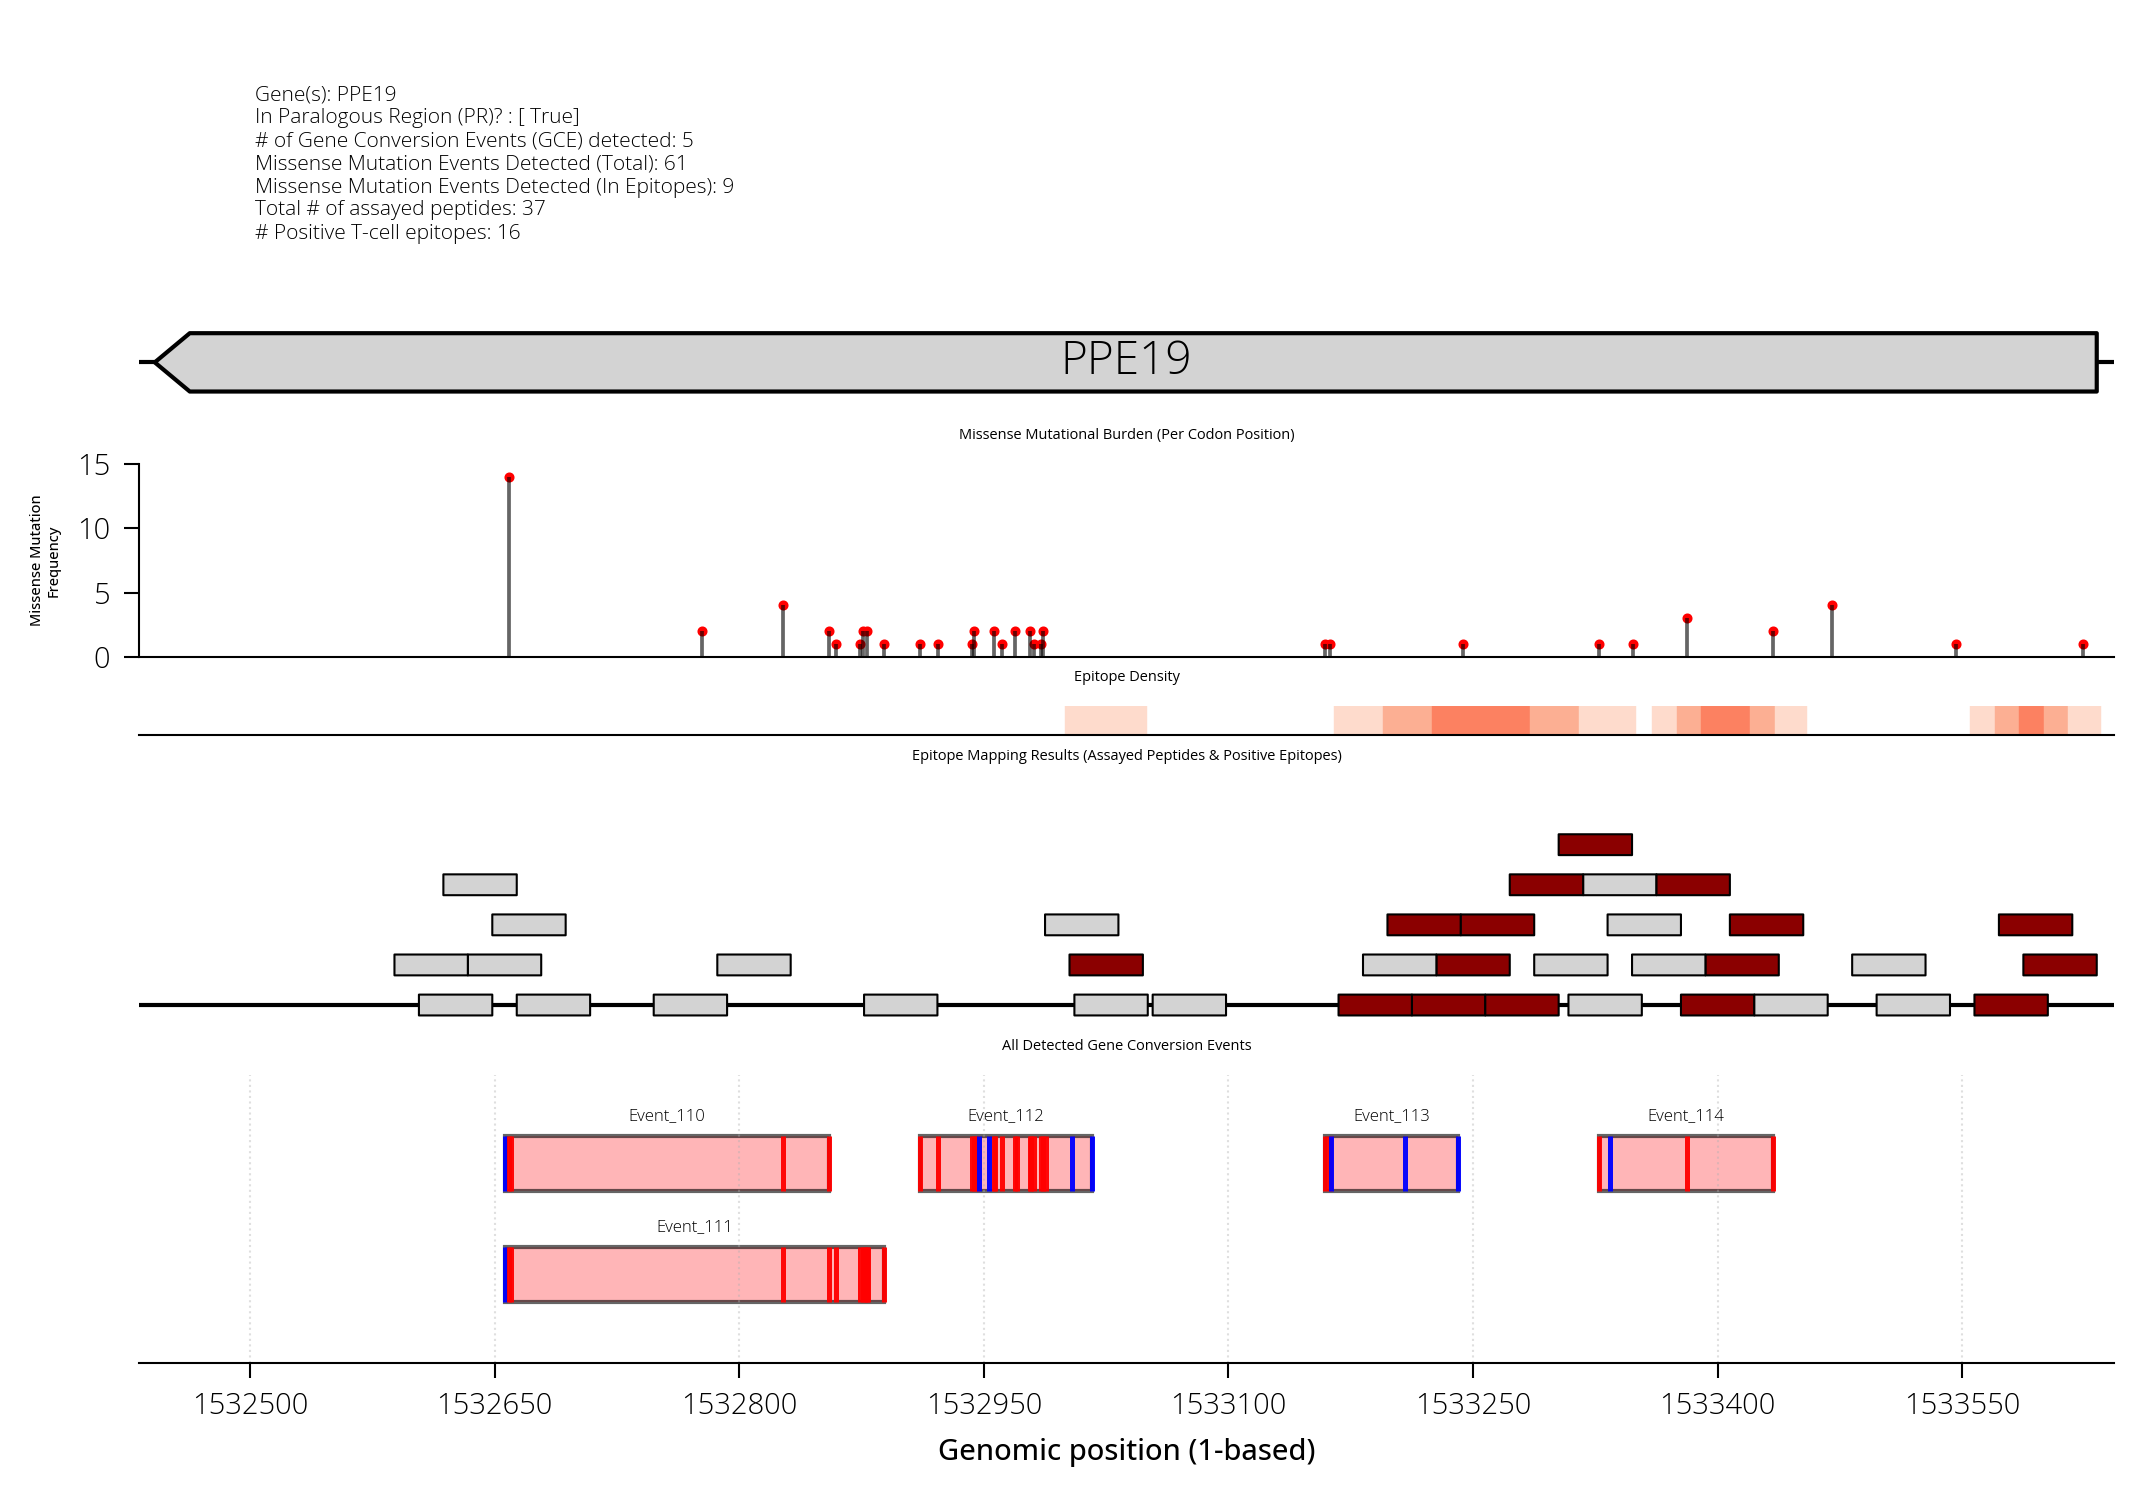

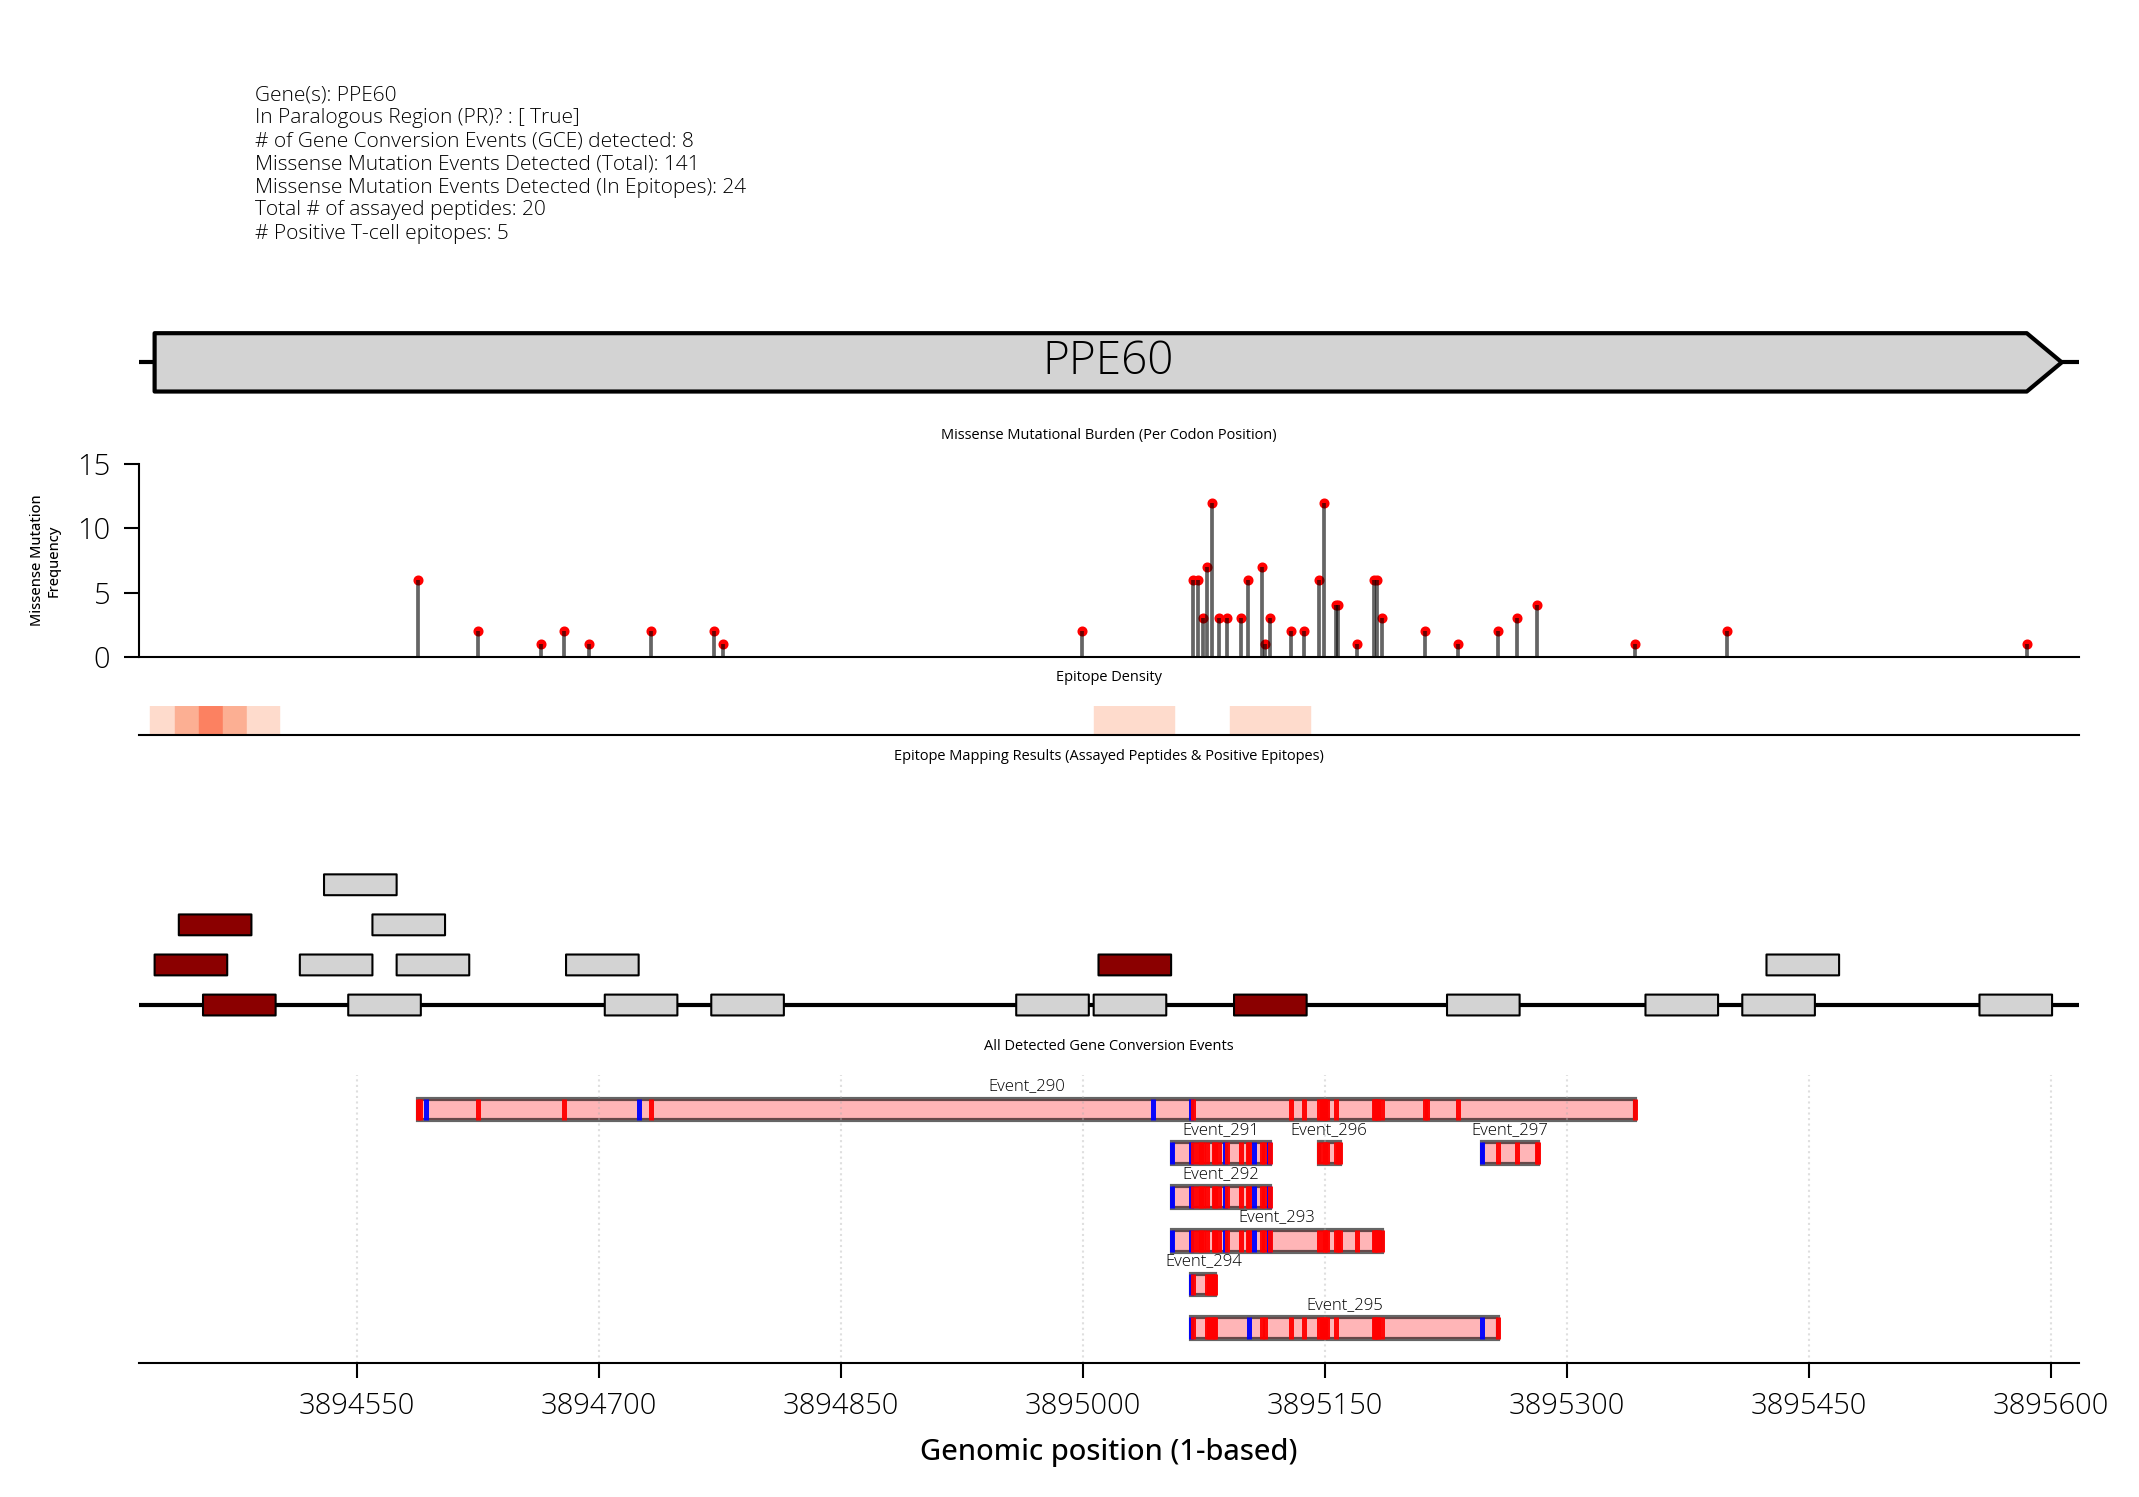

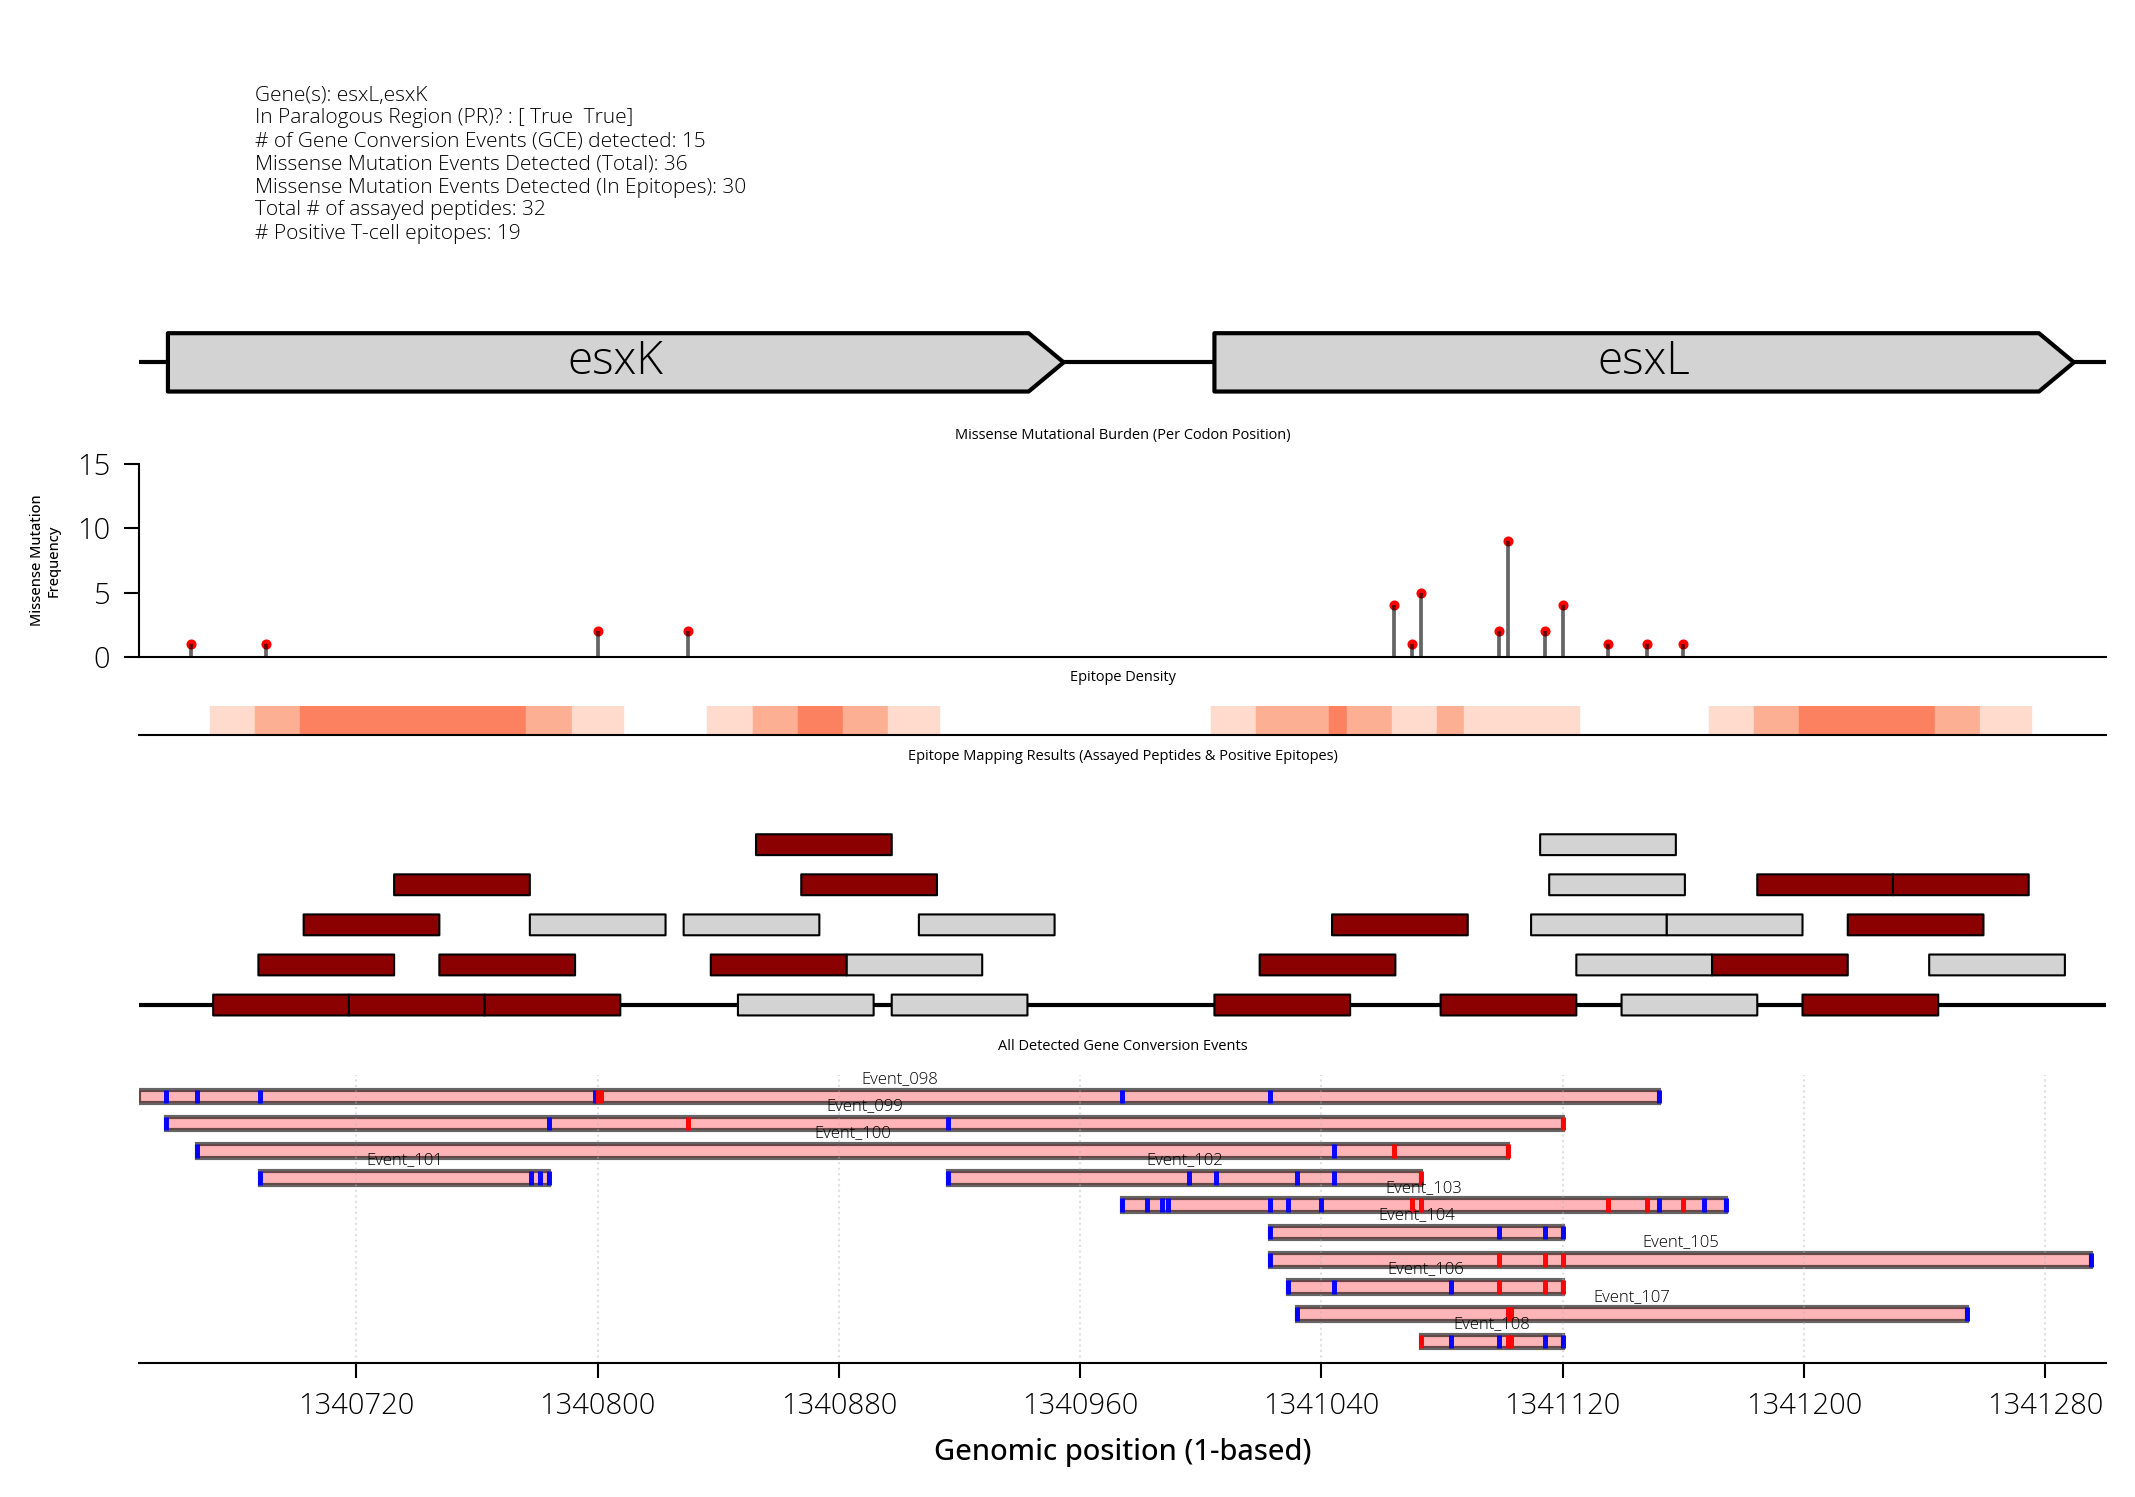

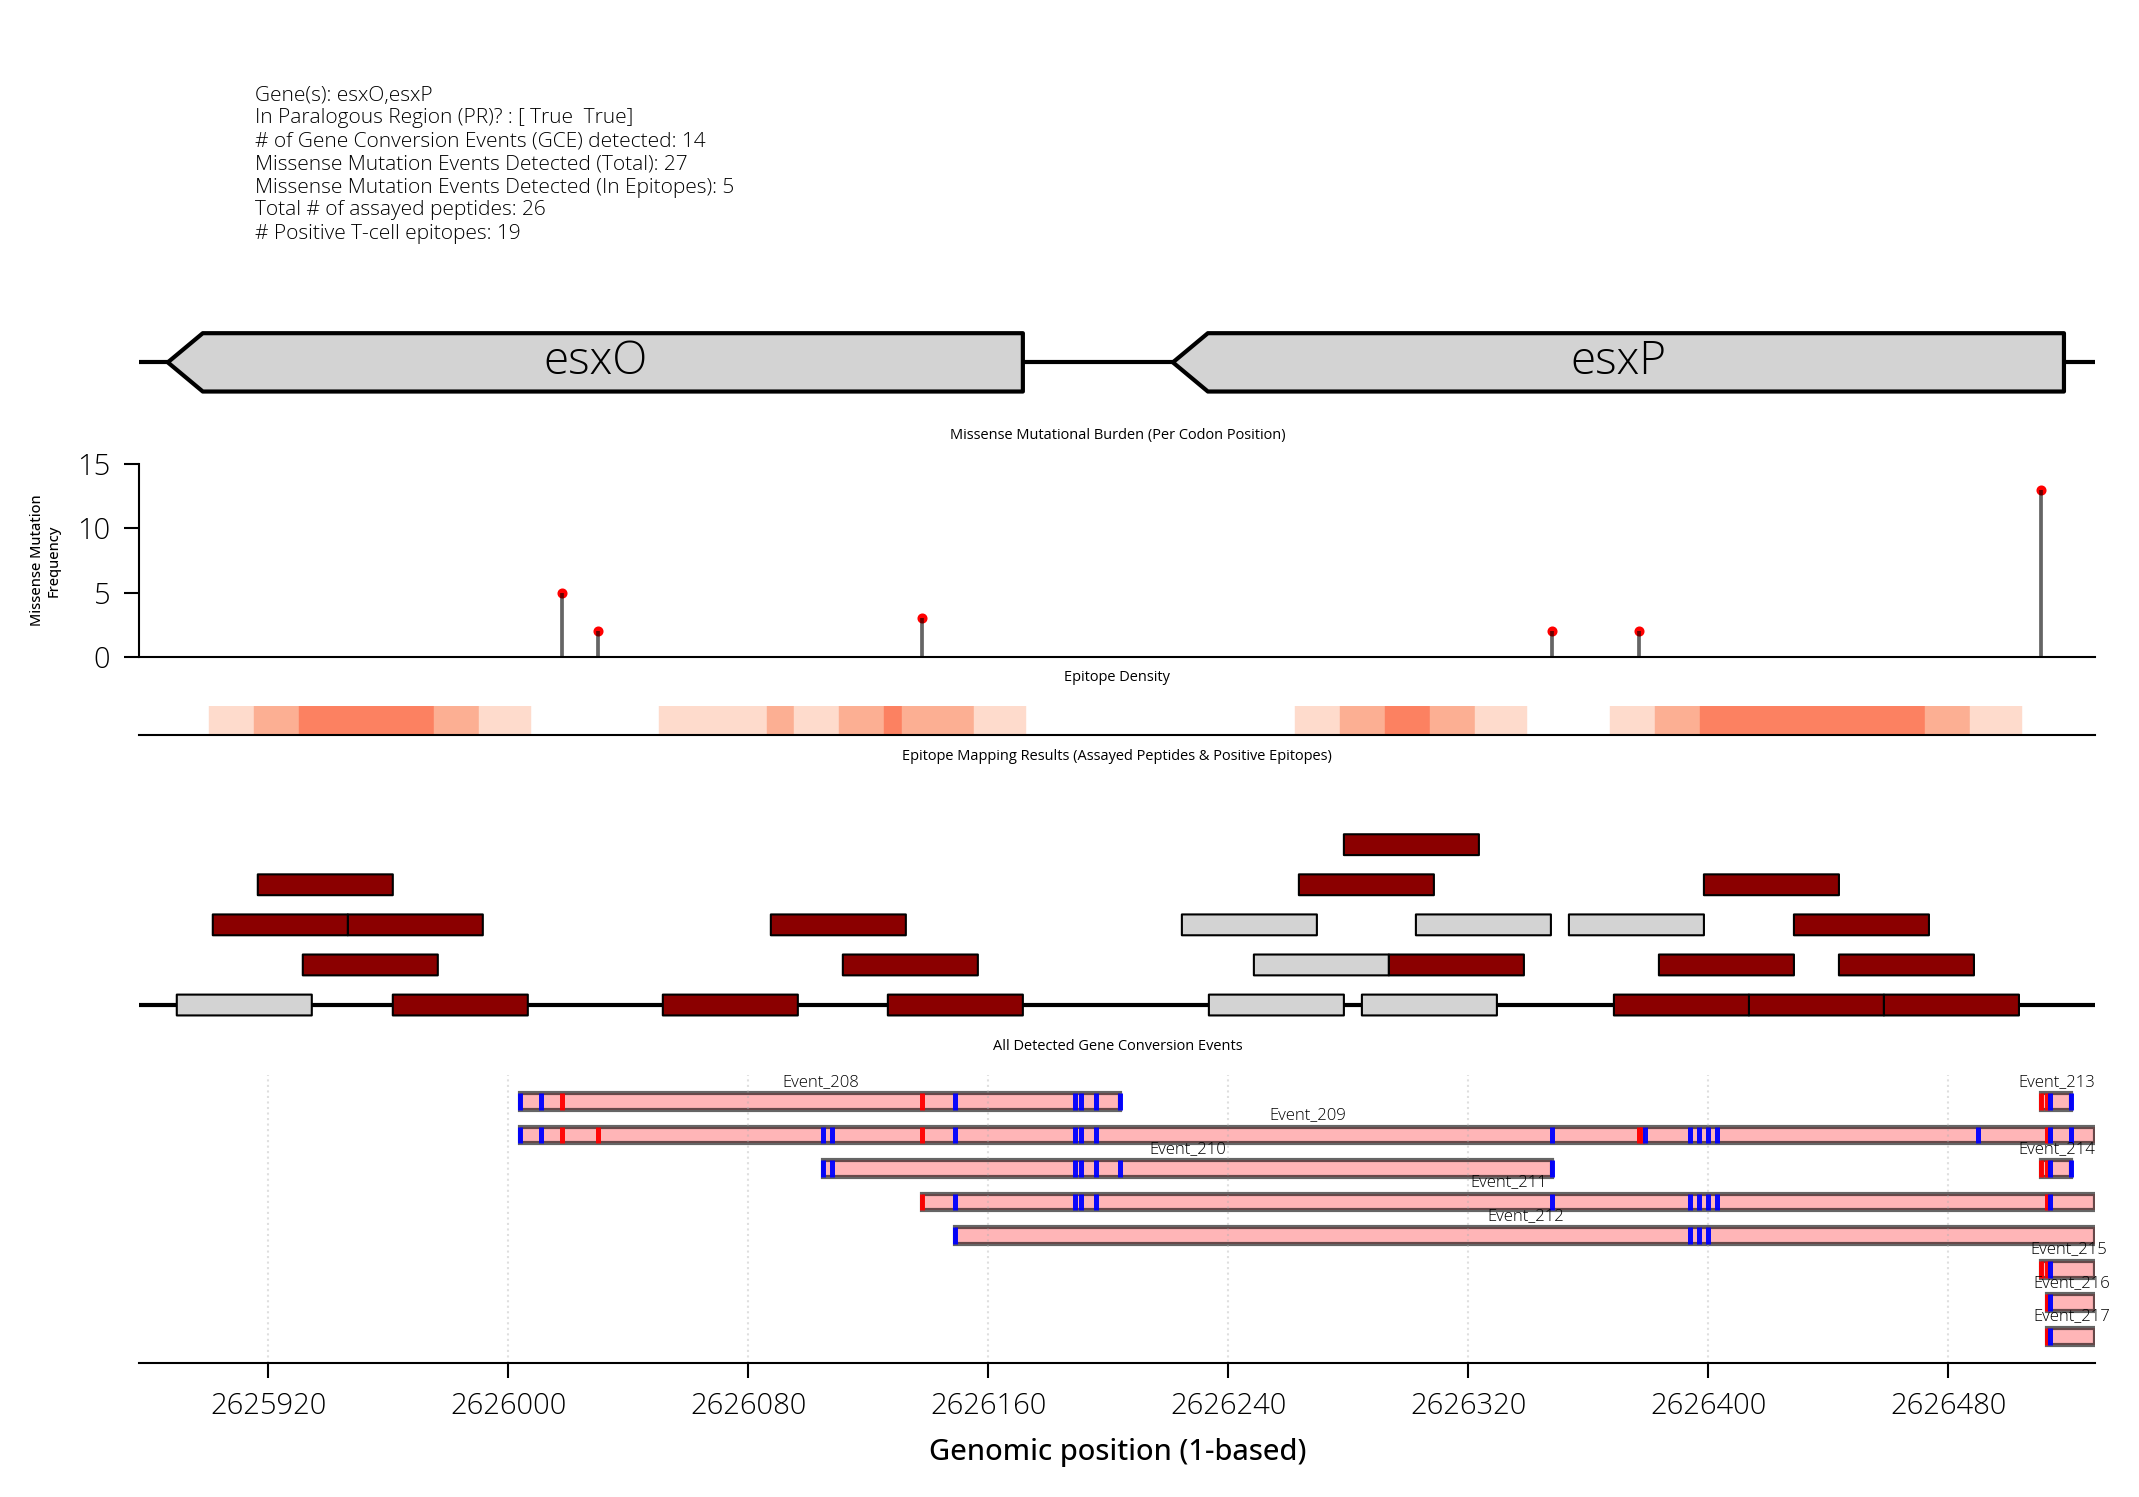

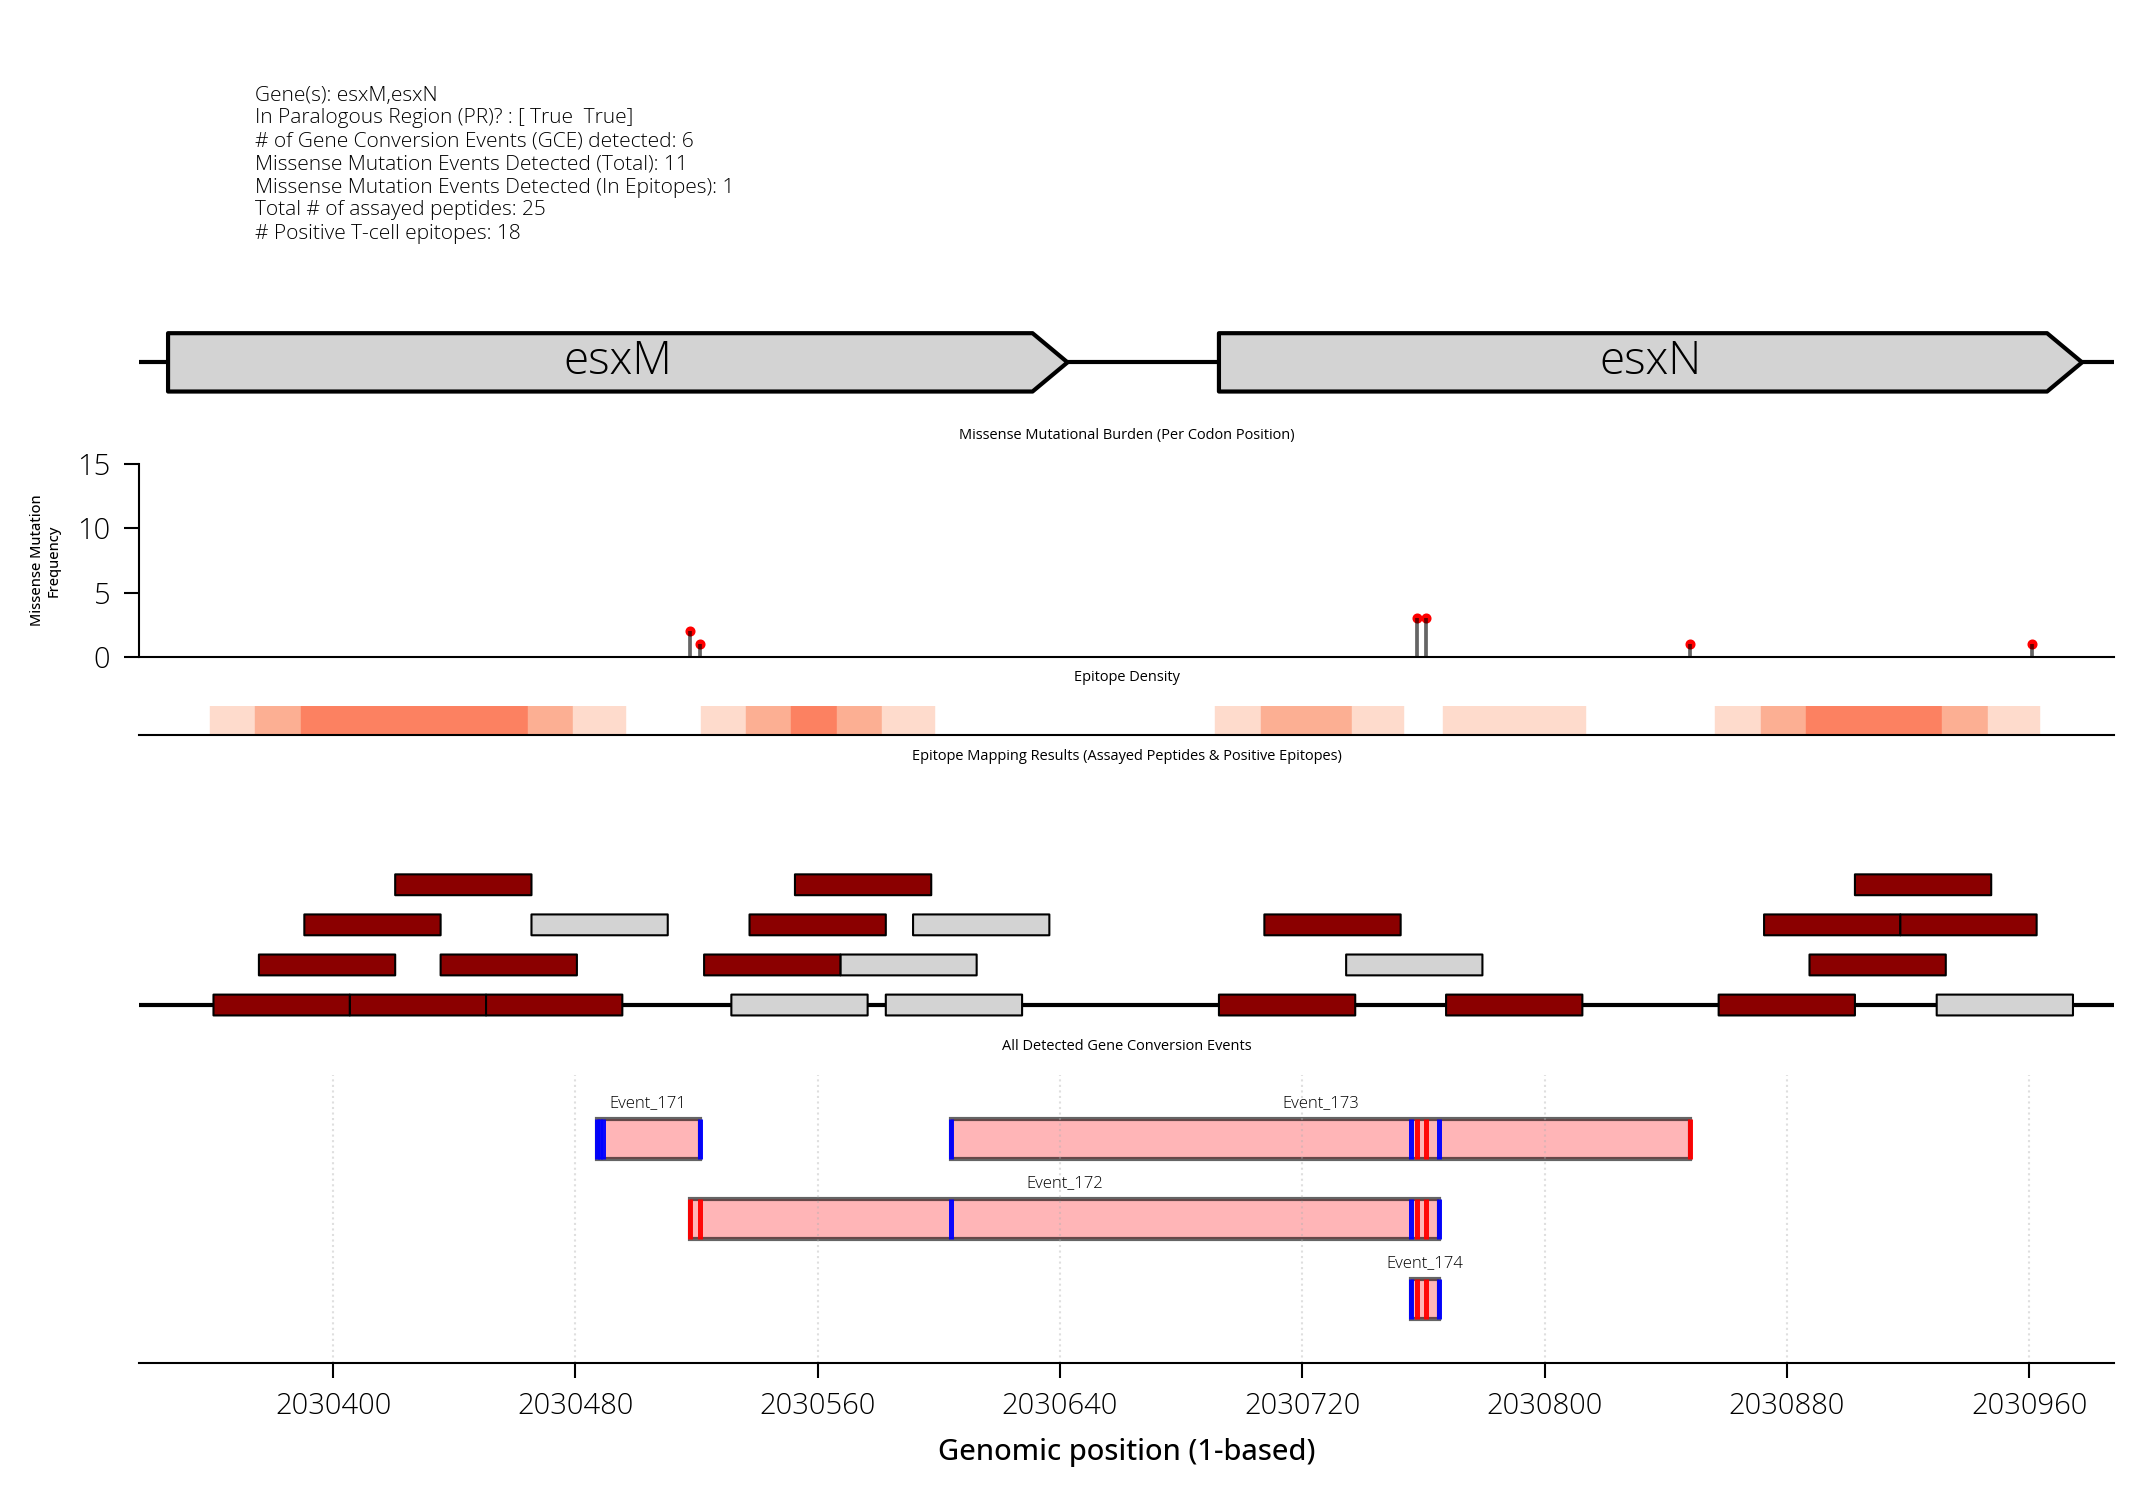

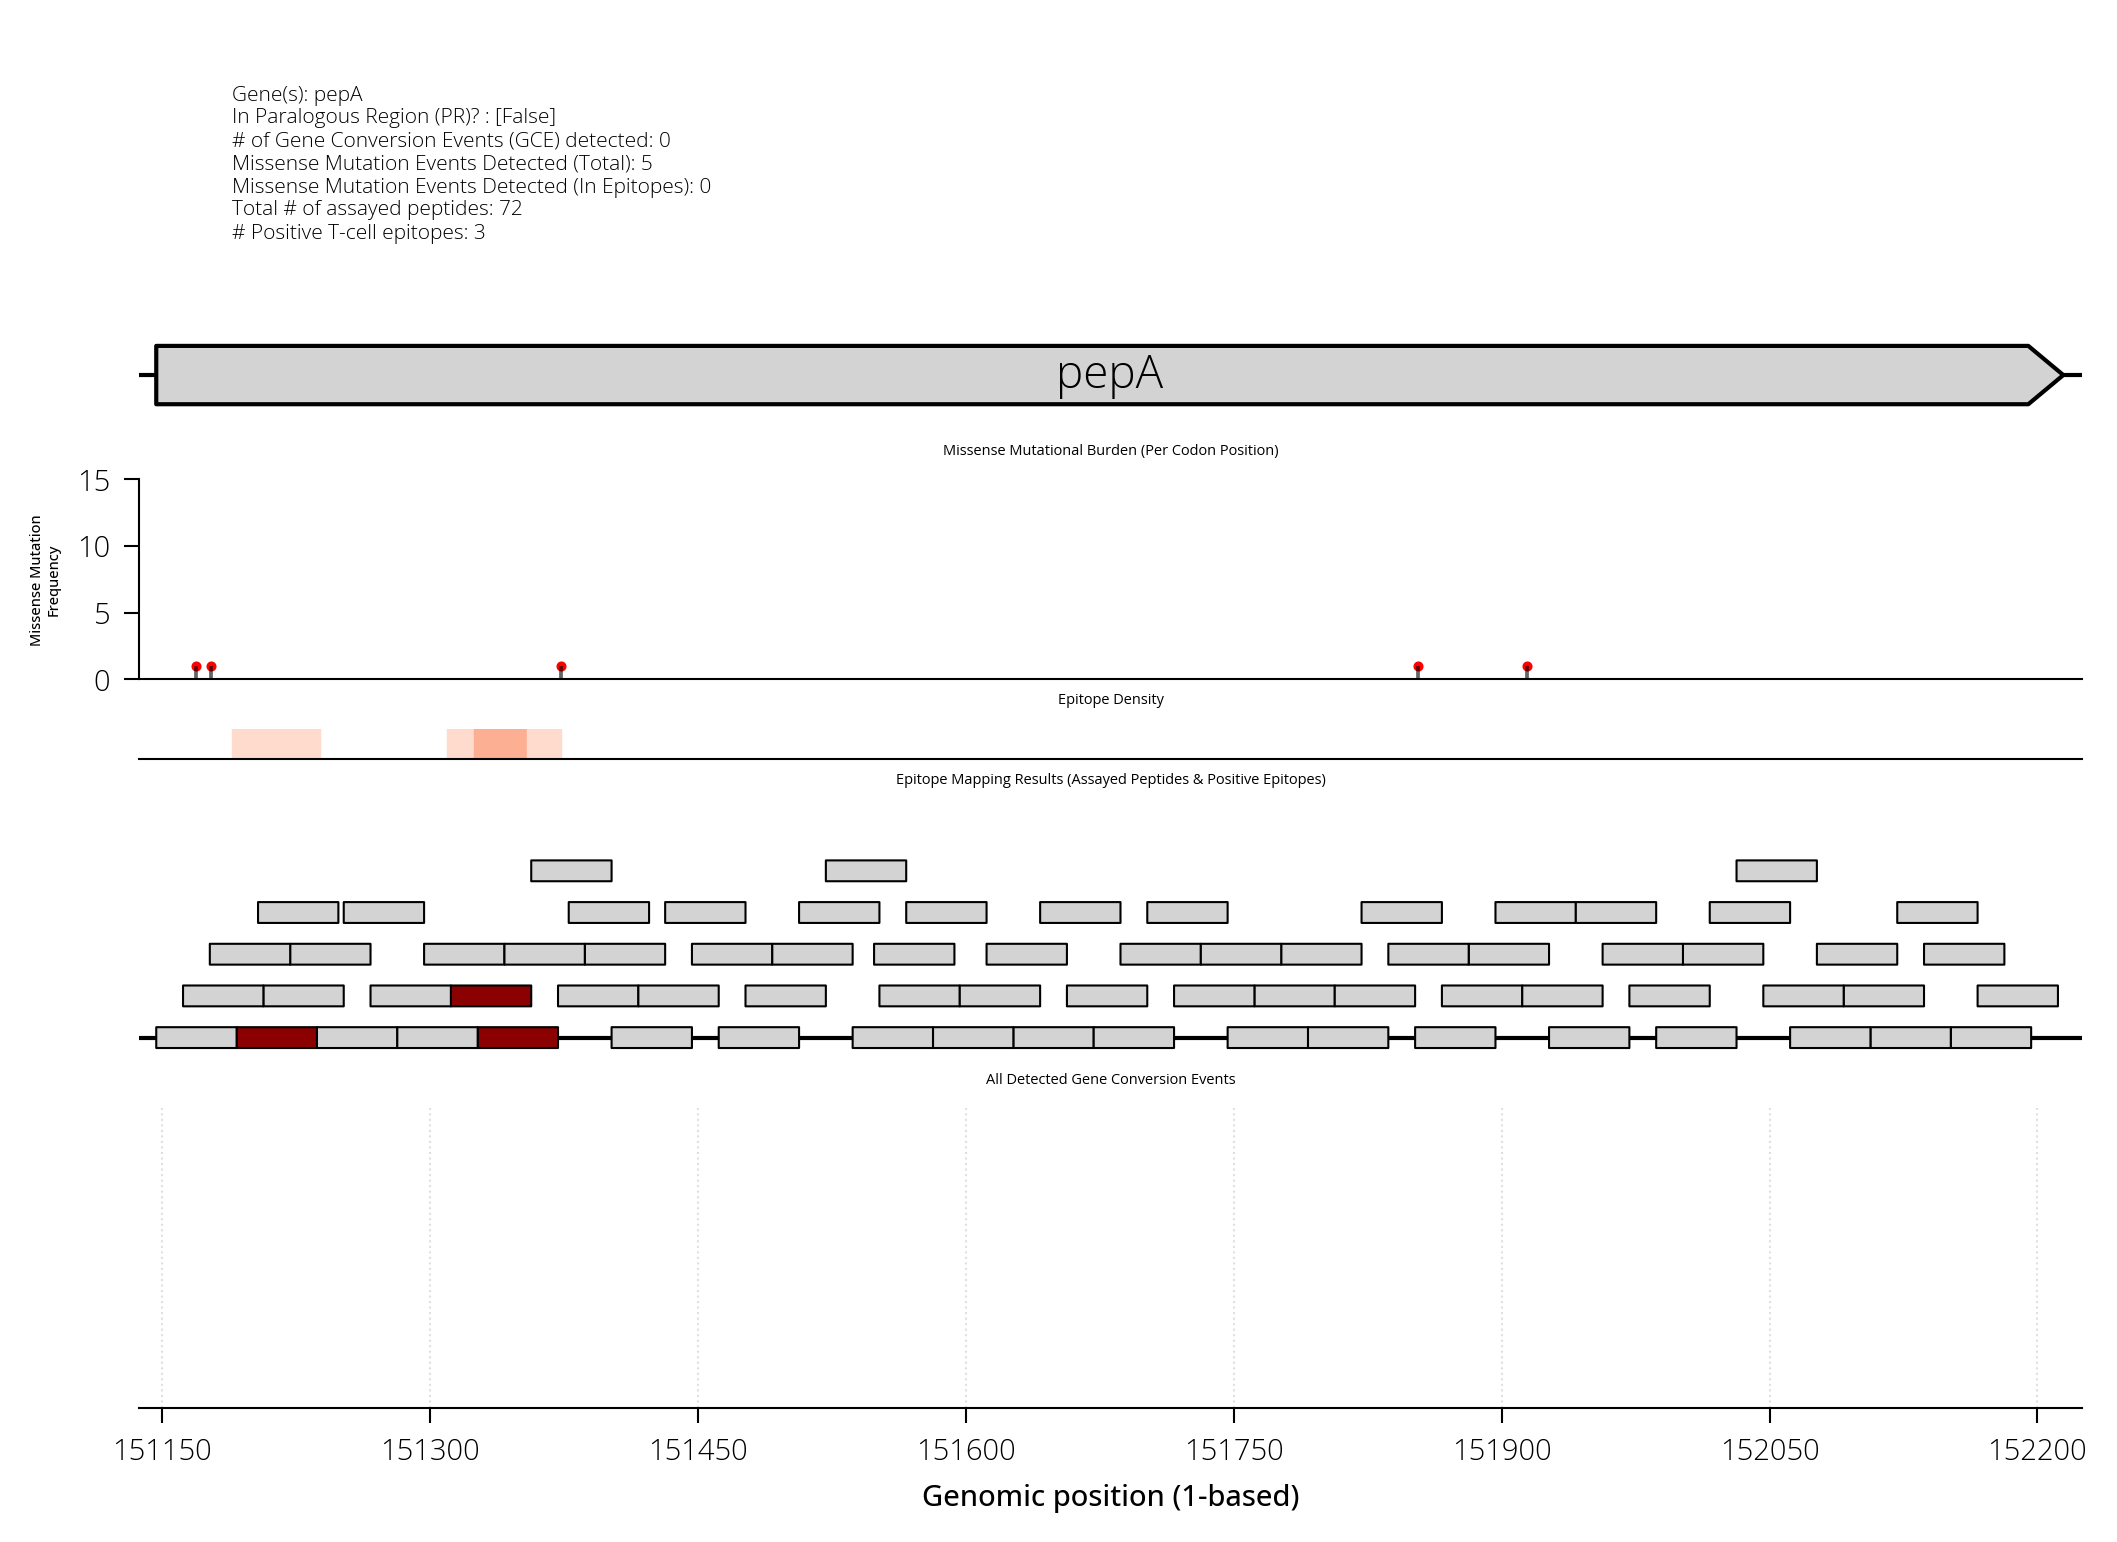

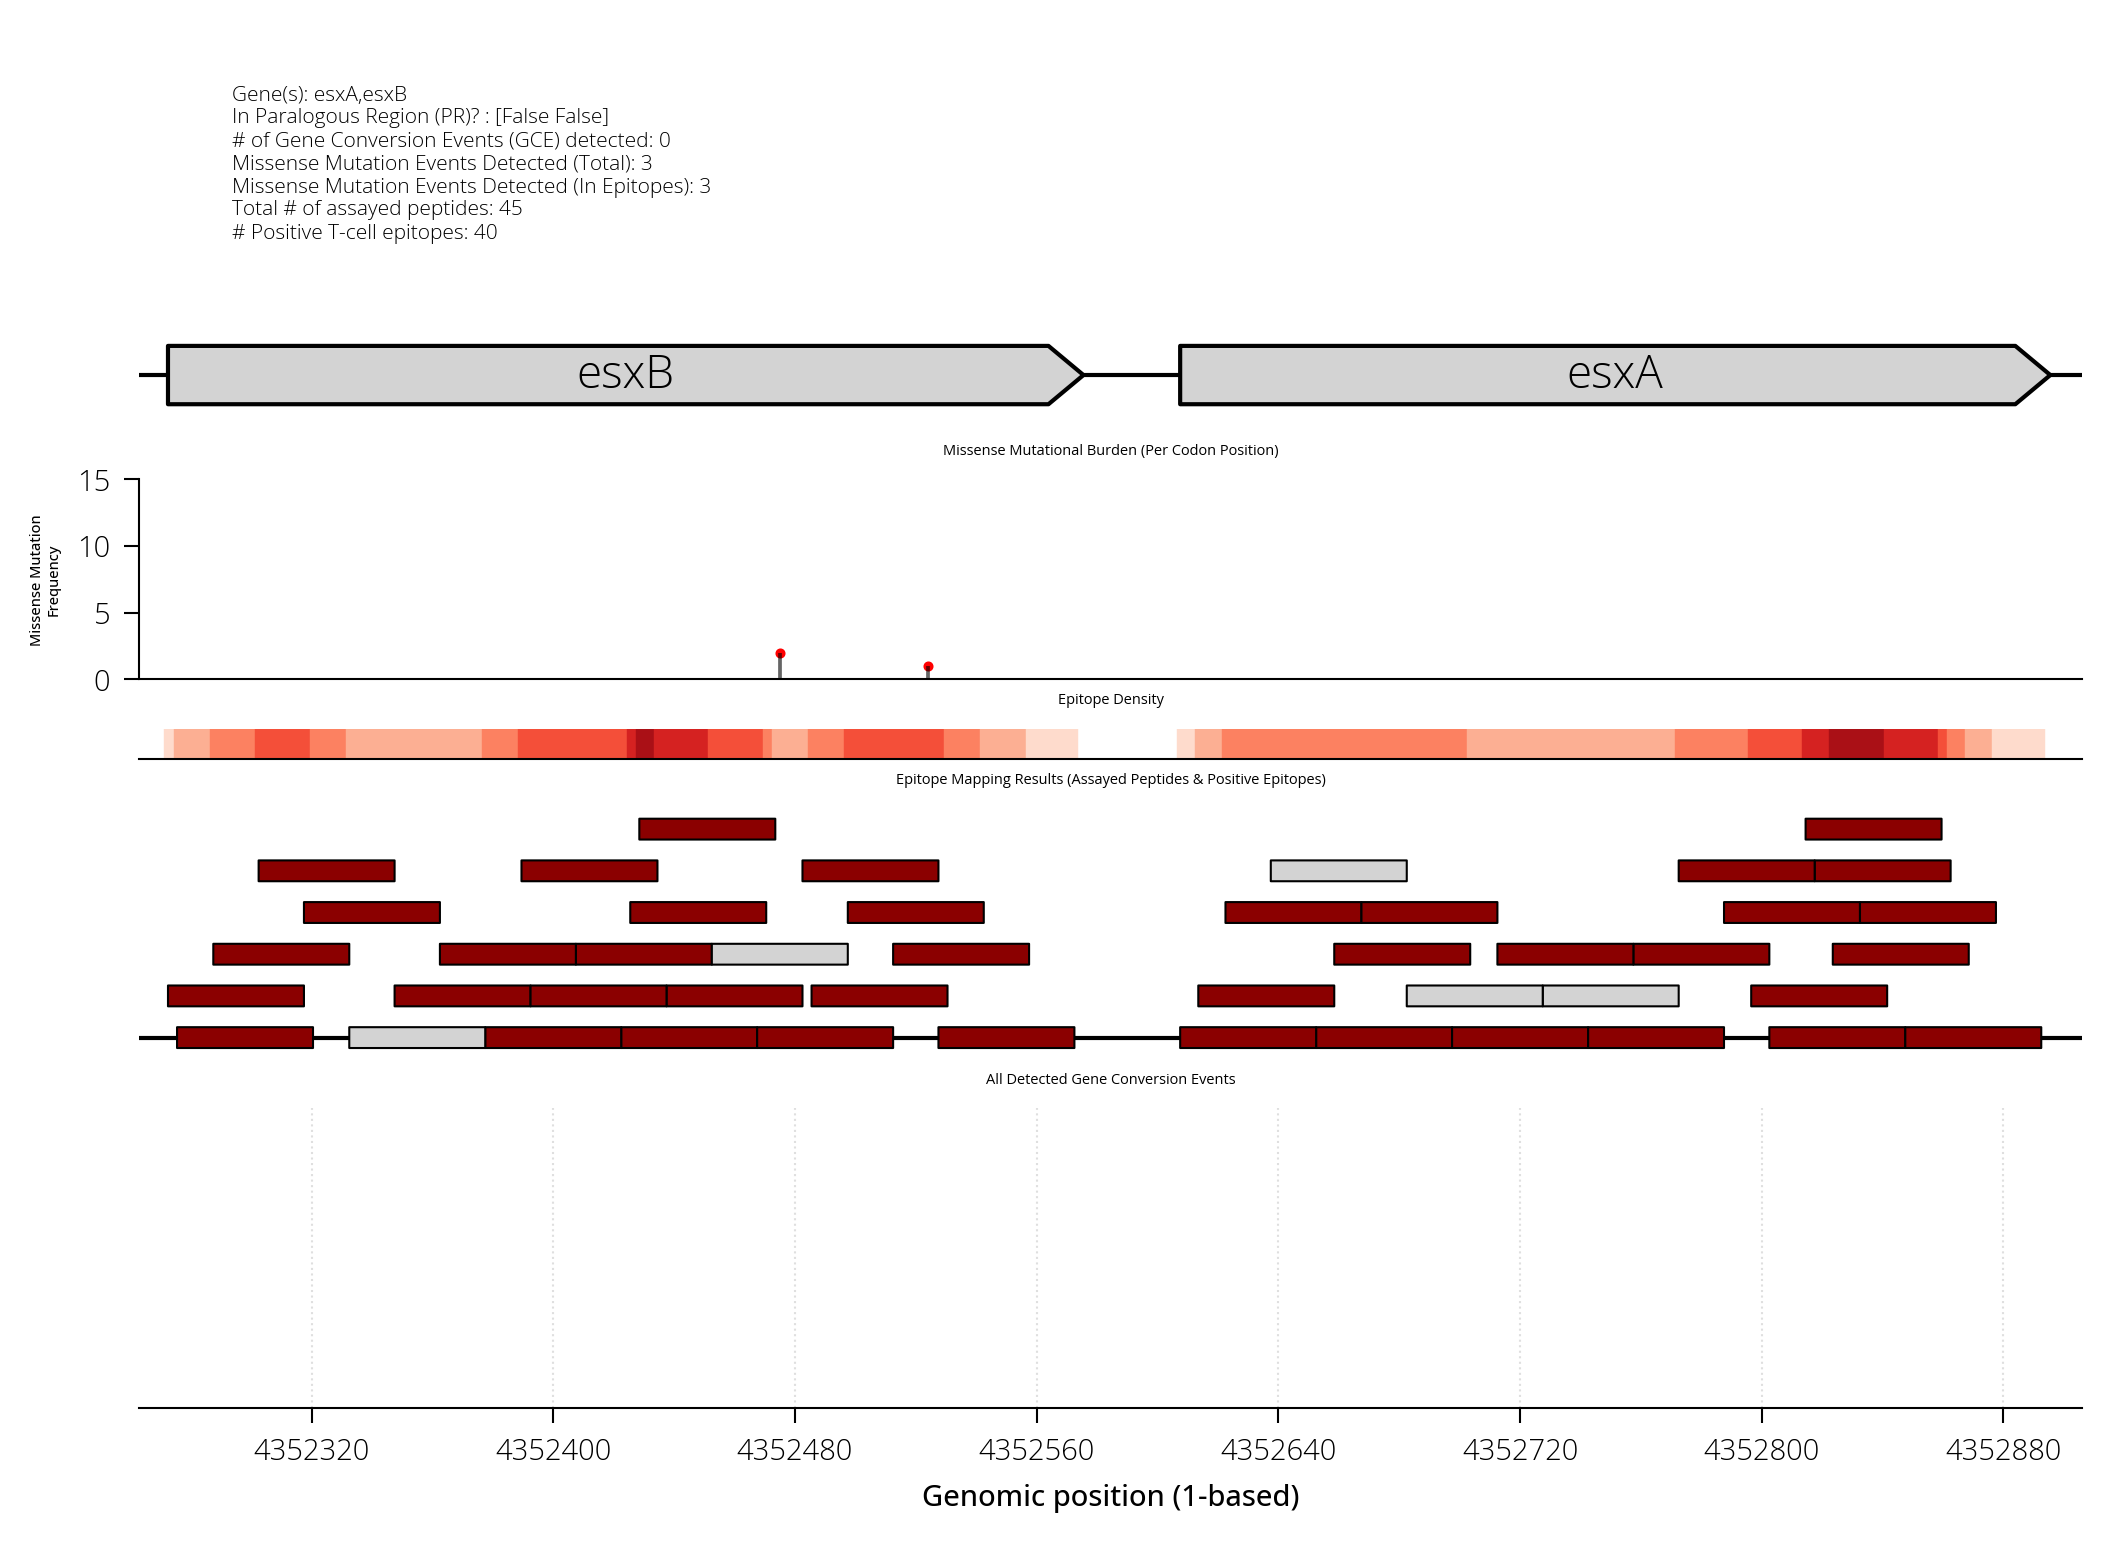

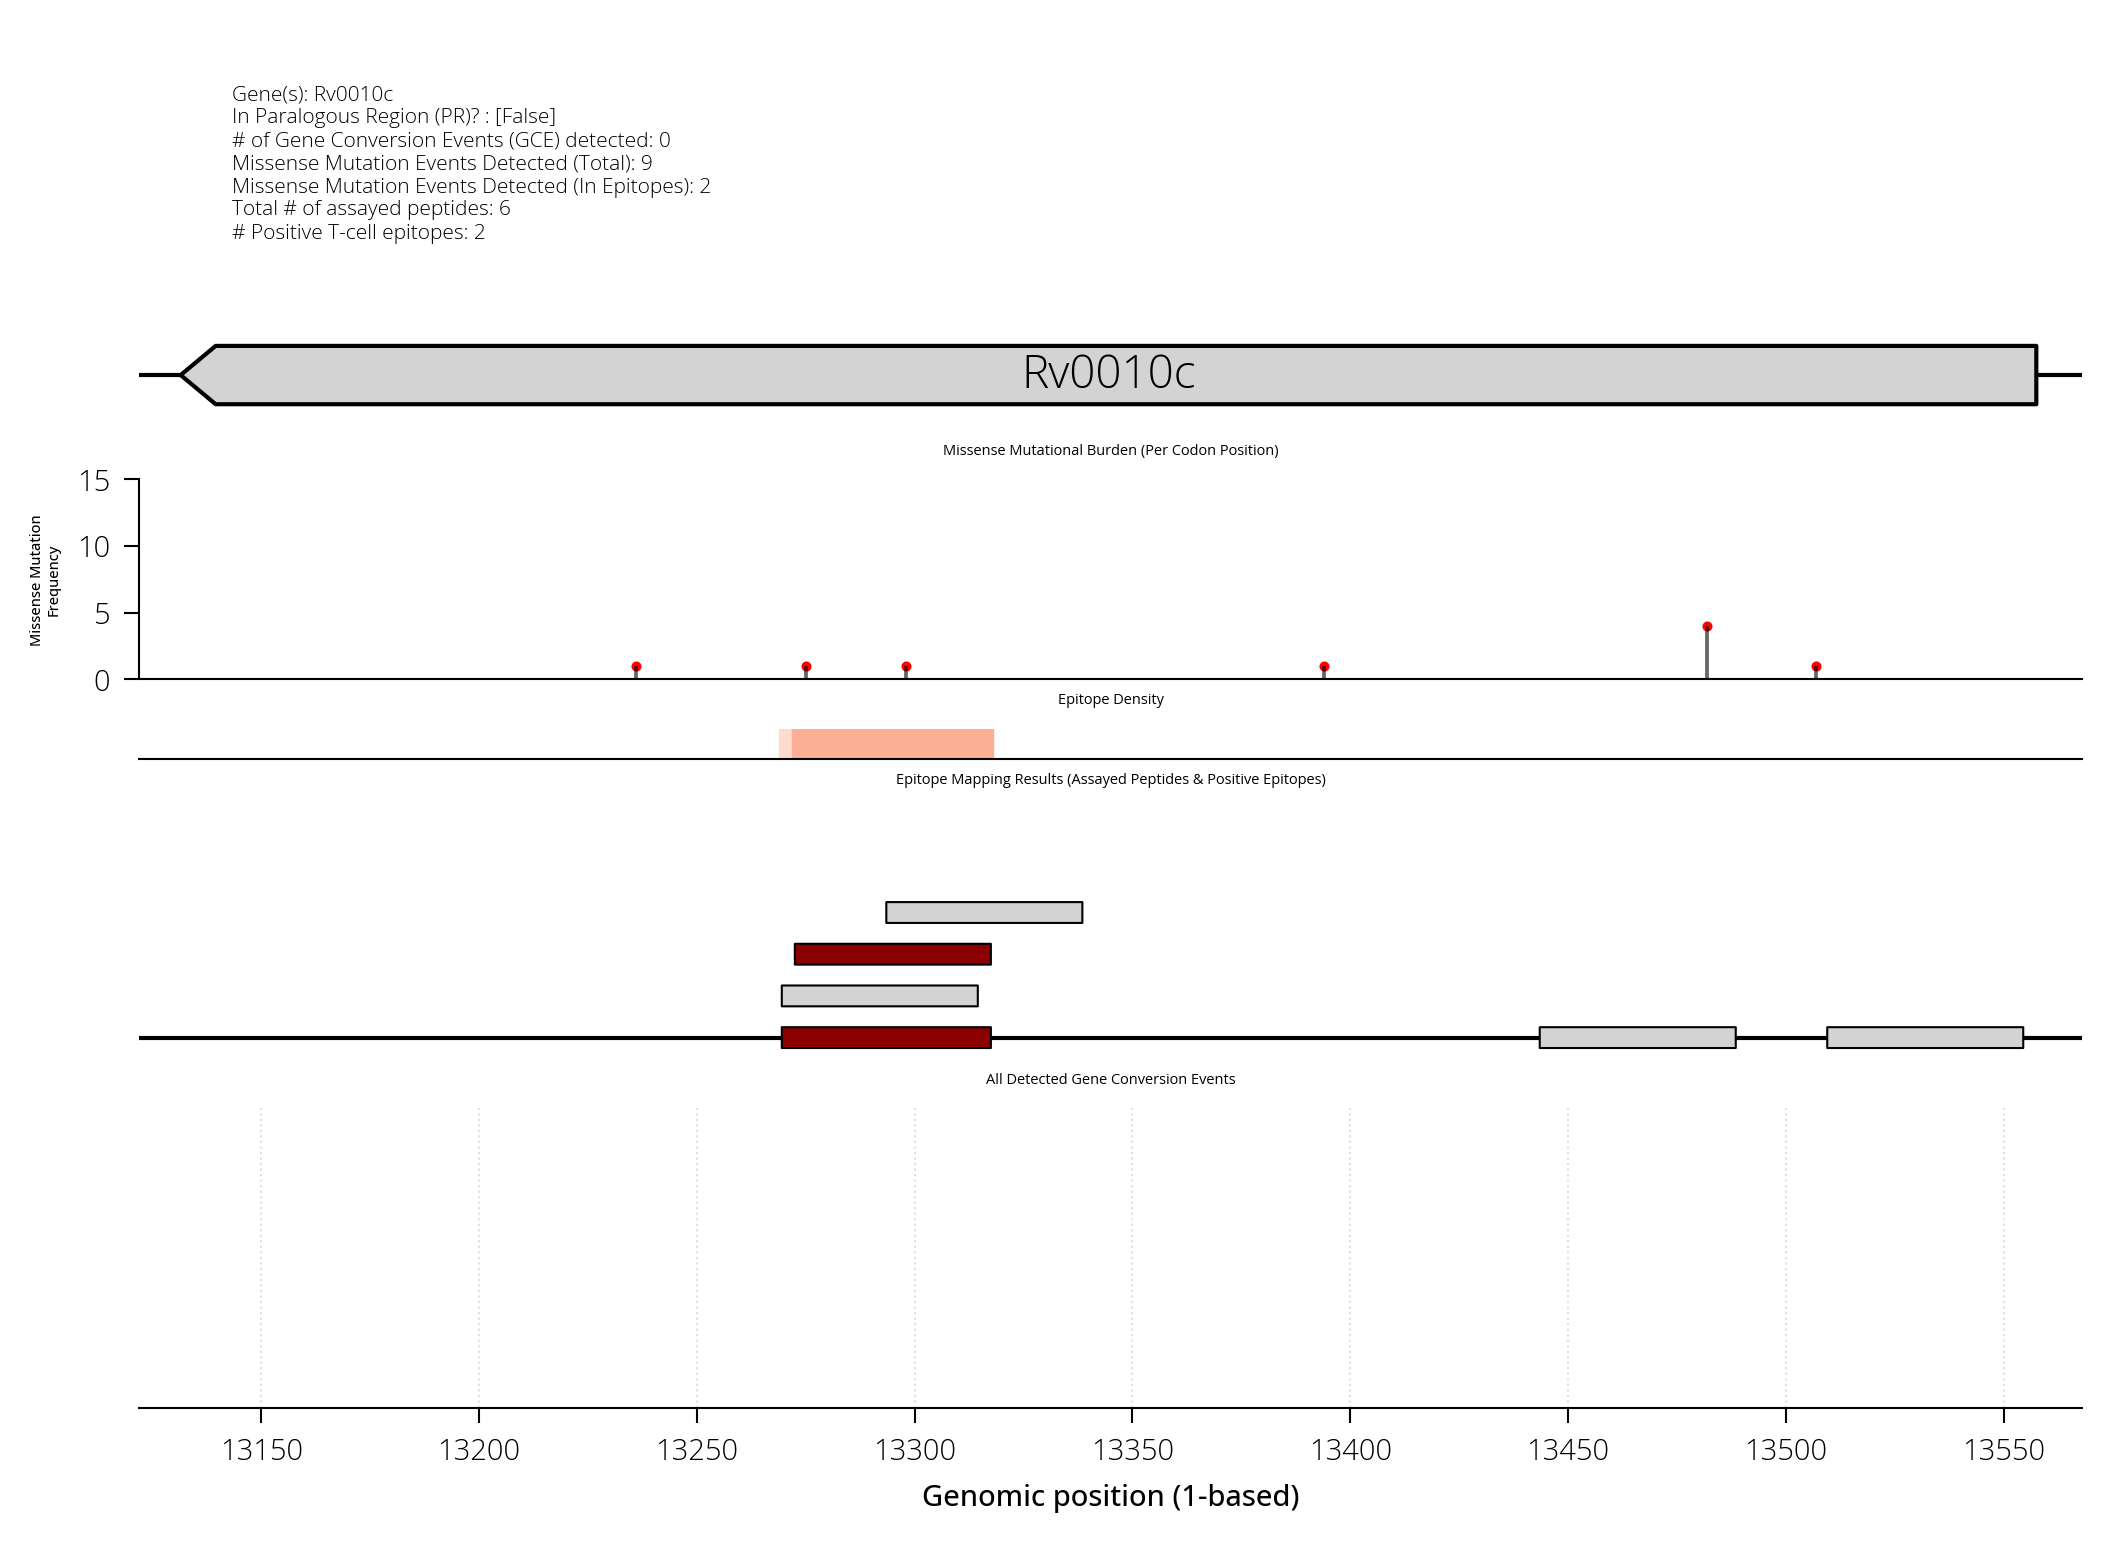

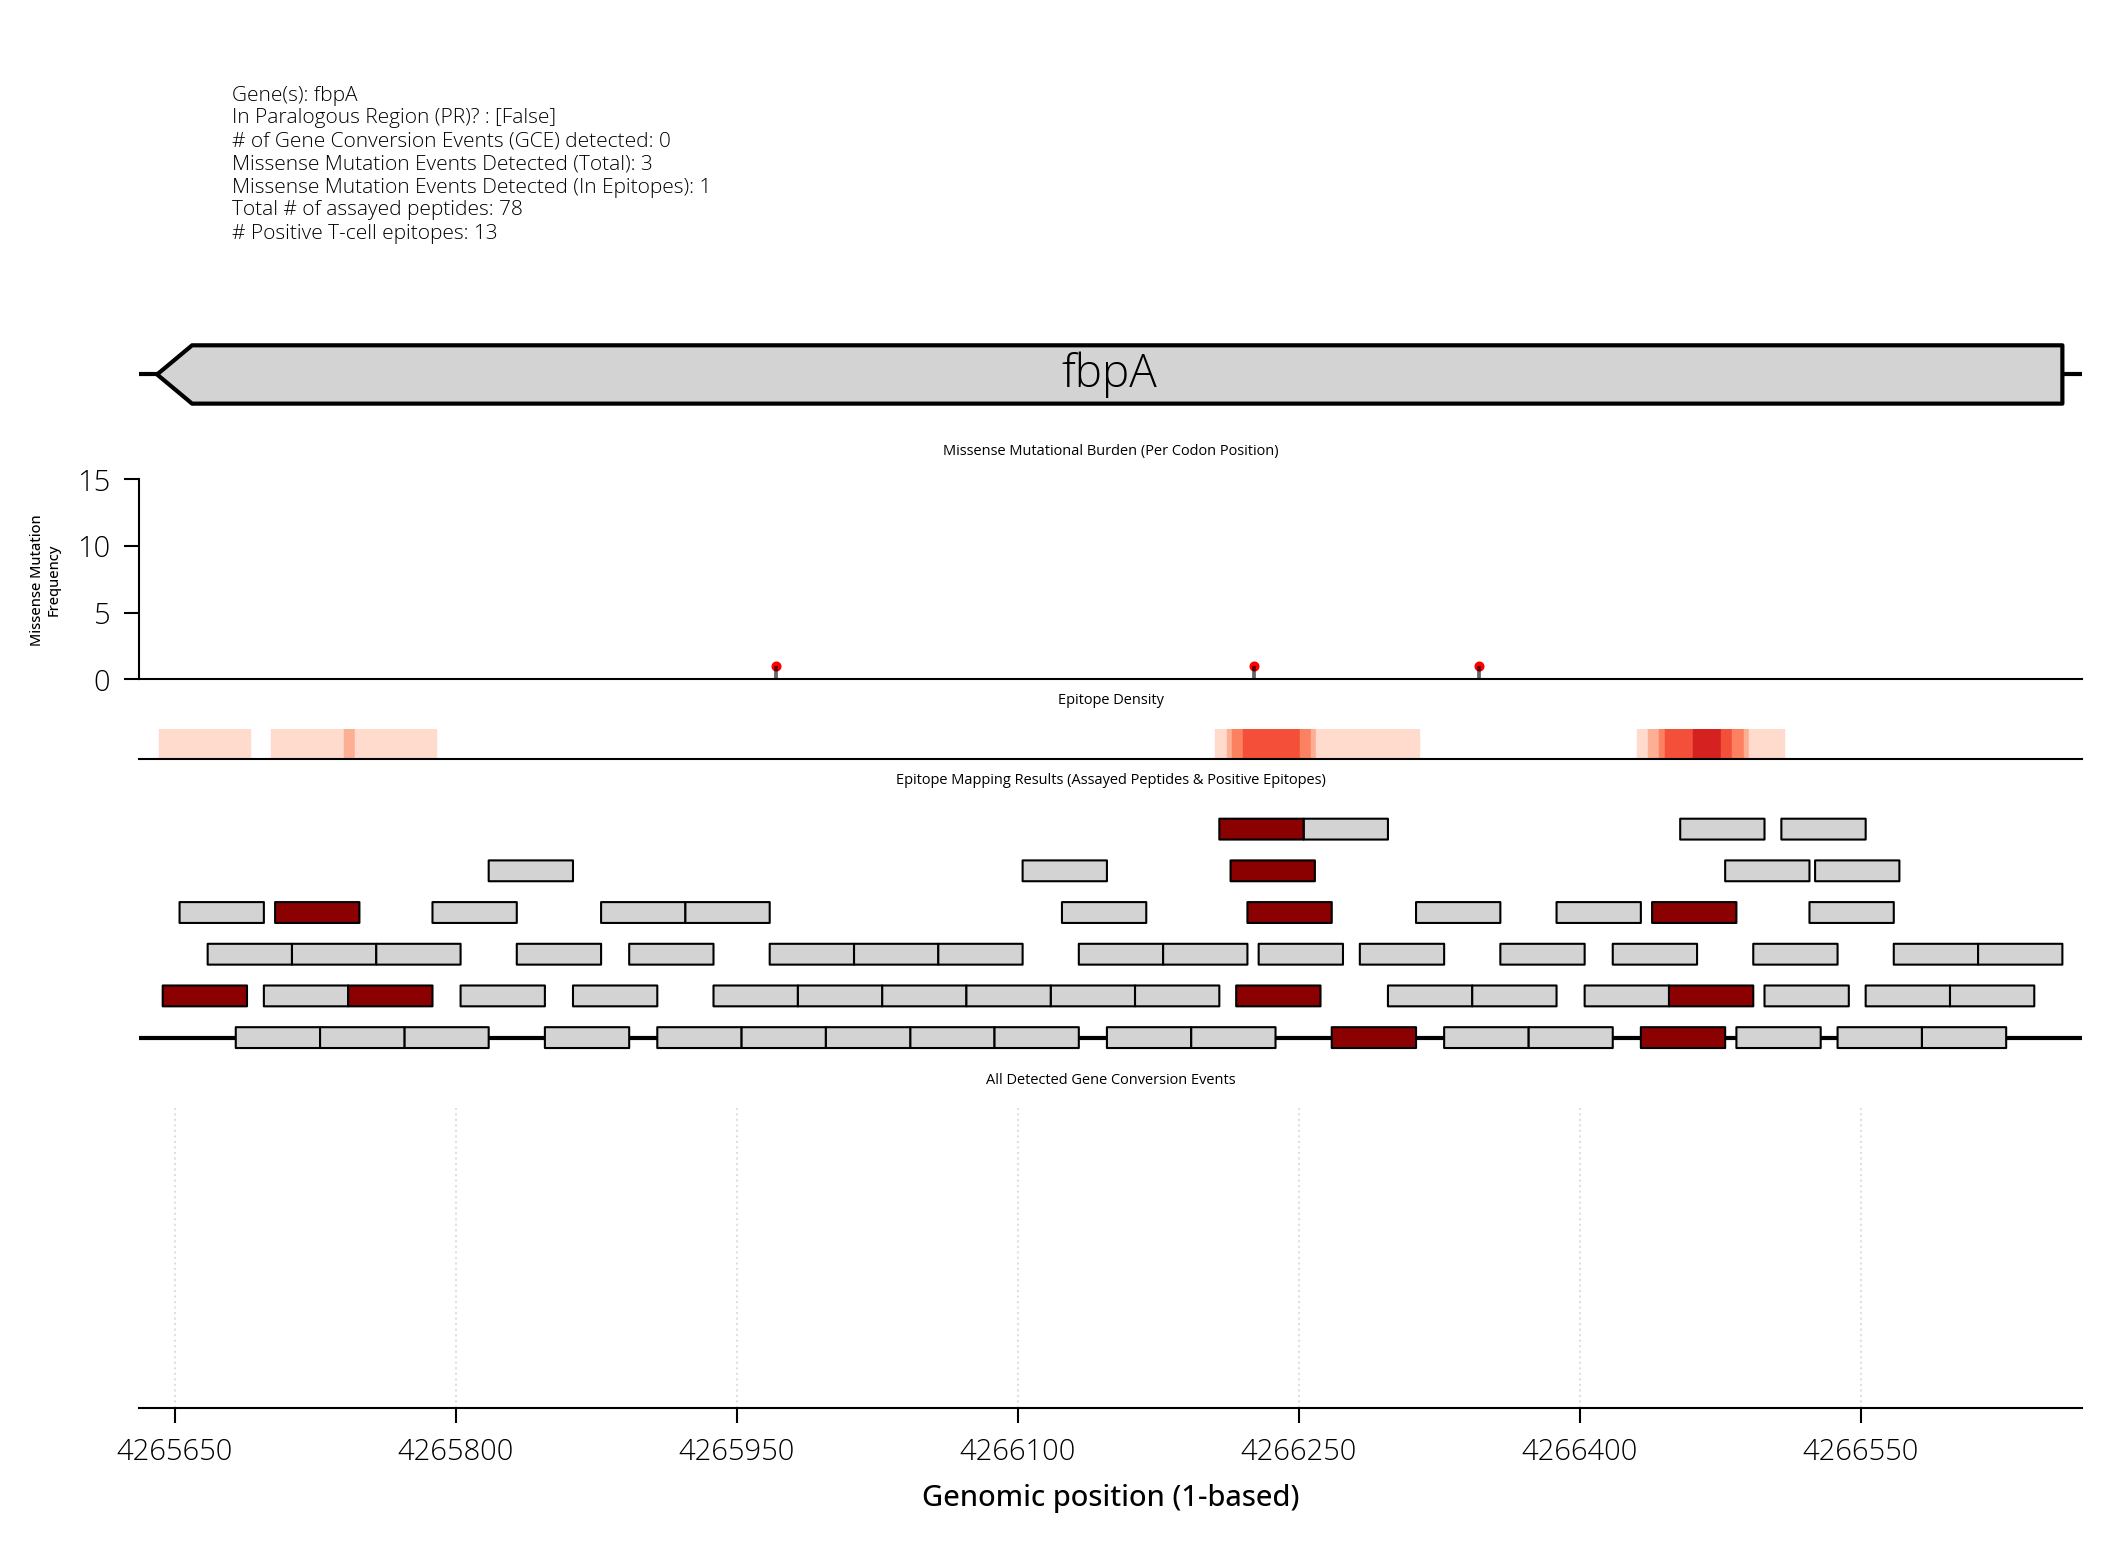

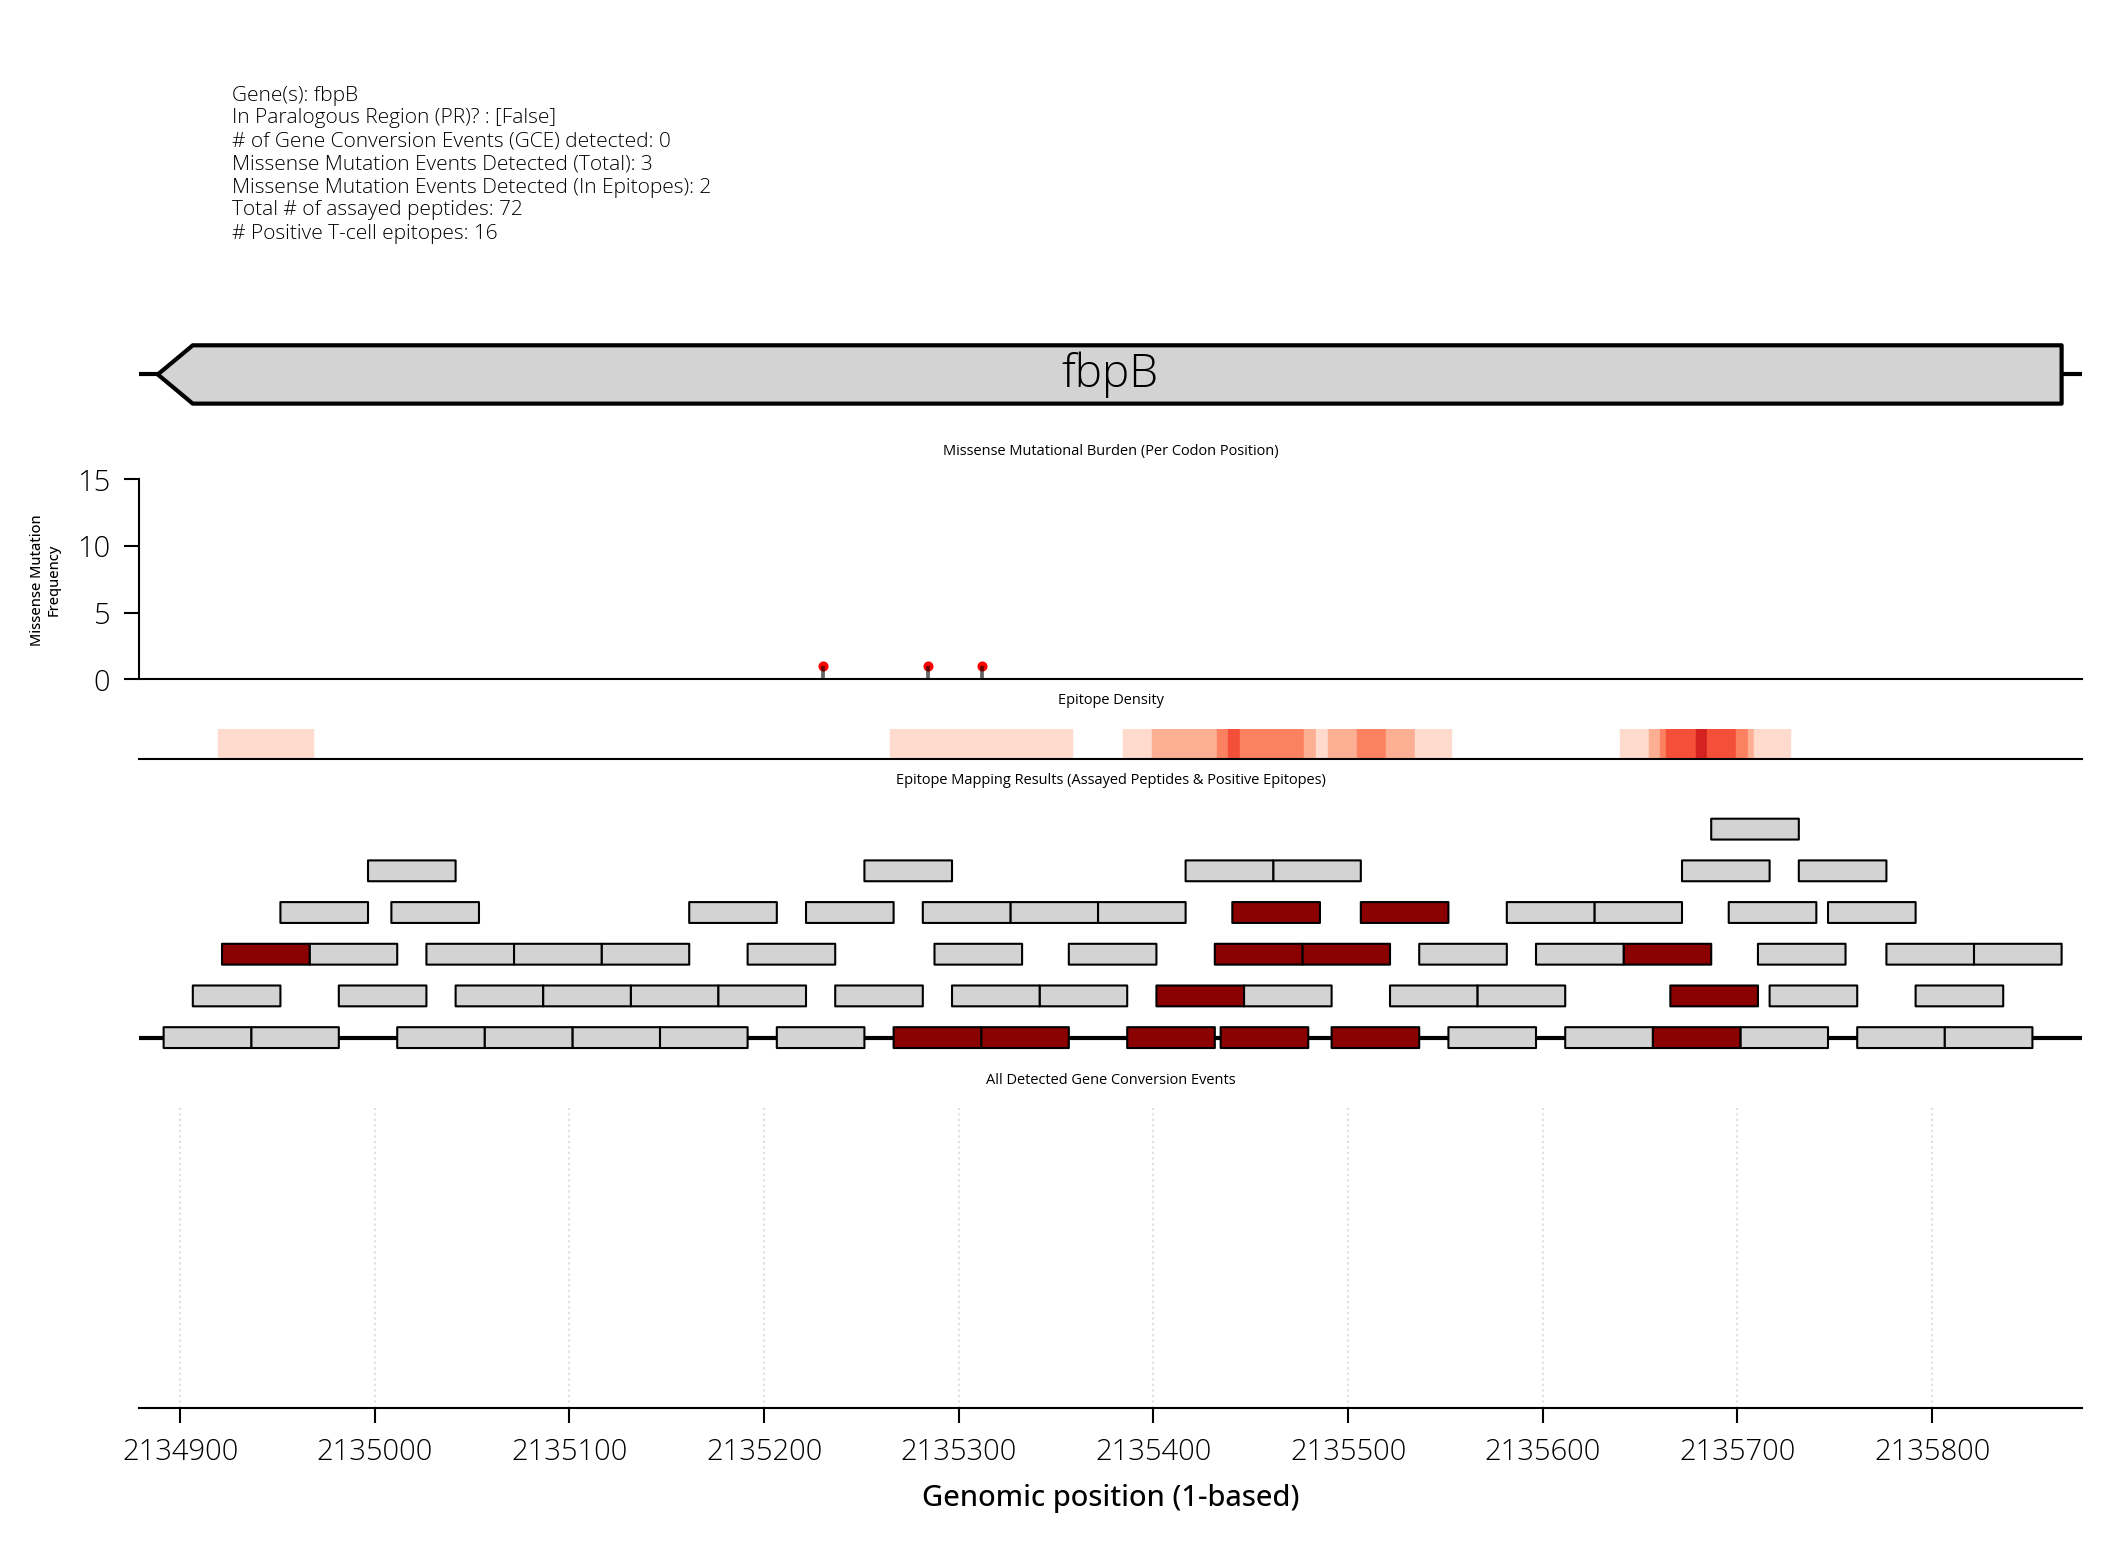

In [615]:
#from matplotlib.ticker import MaxNLocator


in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF


# input_Antigen_Symbols = ["PPE18", "PPE19", "PPE60",
#                          "esxL,esxK", "esxO,esxP",]

# input_Antigen_Symbols = [ "PPE18", "PPE19", "PPE60", "esxK,esxL", "esxO,esxP",
#                          "esxM", "pepA", "esxA,esxB", "Rv0010c", ]

# input_Antigen_Symbols = ["PPE18", "esxM,esxN", "esxA,esxB"]

input_Antigen_Symbols = ["PPE18", "PPE19", "PPE60",
                         "esxL,esxK", "esxO,esxP", "esxM,esxN",
                         # "esxI,esxJ", "esxV,esxW", 
                         "pepA", "esxA,esxB", "Rv0010c", "fbpA", "fbpB"]

# input_Antigen_Symbols = [ "pepA", "esxA,esxB"]

# input_Antigen_Symbols = ["esxM,esxN" ]


View_Counter = 1

for i_Symbol in input_Antigen_Symbols:

    i_Symbol_List = i_Symbol.split(",")
    i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

    i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
    i_Gene_End = i_Gene_MutInfo_DF["End"].max()
    
    Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10
    
    i_N_Mut_Total = sum( i_Gene_MutInfo_DF["Total_NS_Muts"].values ) #[0]
    i_N_Mut_InEpitope = sum( i_Gene_MutInfo_DF["Total_NS_Muts_InEpitope"].values ) #[0]

    i_Gene_N_Epitopes = sum( i_Gene_MutInfo_DF["N_Pos"].values ) #[0]
    i_Gene_N_NegPeptide = sum( i_Gene_MutInfo_DF["N_Neg"].values ) #[0]
    i_Gene_N_PeptidesAssayed = sum( i_Gene_MutInfo_DF["Total"].values ) #[0]

    i_Gene_InHHR = i_Gene_MutInfo_DF["HasHmRegion"].values  

    i_N_GCEs_Ovrlap = sum(i_Gene_MutInfo_DF["pGCE_Ovrlap"].values ) #[0]

    GeneInfo_StrList = []
    GeneInfo_StrList.append( "Gene(s): " + i_Symbol)
    GeneInfo_StrList.append( "In Paralogous Region (PR)? : " + str(i_Gene_InHHR))
    GeneInfo_StrList.append( "# of Gene Conversion Events (GCE) detected: " + str(i_N_GCEs_Ovrlap))

    GeneInfo_StrList.append( "Missense Mutation Events Detected (Total): " + str(int(i_N_Mut_Total))   )
    GeneInfo_StrList.append( "Missense Mutation Events Detected (In Epitopes): " +  str(int(i_N_Mut_InEpitope))  )
    #GeneInfo_StrList.append("")
    GeneInfo_StrList.append( "Total # of assayed peptides: " +  str(int(i_Gene_N_PeptidesAssayed)) )
    GeneInfo_StrList.append( "# Positive T-cell epitopes: " +  str(int(i_Gene_N_Epitopes))  )
    #GeneInfo_StrList.append( "# Negative peptides (non-reactive): " +  str(int(i_Gene_N_NegPeptide))  )

    print("\n".join(GeneInfo_StrList))
    print("\n")

    if i_N_GCEs_Ovrlap >= 0:
        i_G_fig, i_G_axes = plot_mut_epitope_region_with_gce_V2(Viz_Start = Viz_Start, Viz_End = Viz_End,
                                                                in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF,
                                                                in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                                                in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord,
                                                                in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF,
                                                                pGCE_df = pGCE_DF,
                                                                snps_df = Gub_SNPs_V2_DF,
                                                                gce_label_fontsize = 4,
                                                                mut_ylim=(0, 15),
                                                                height_ratios = (4, 2, 0.3, 2.5, 3),
                                                                figsize = (7, 5),
                                                                )

        i_G_axes["GCE_ax"].set_title("All Detected Gene Conversion Events", fontsize = 3.5)
        i_G_axes["GCE_ax"].ticklabel_format( axis="x", style="plain", useOffset=False )
        i_G_axes["GCE_ax"].set_xlim(Viz_Start, Viz_End)
        i_G_axes["GCE_ax"].set_xlabel("Genomic position (1-based)")
        i_G_axes["GCE_ax"].set_yticks([])
        i_G_axes["GCE_ax"].grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.4)
        
        for spine in ("left", "top", "right"): i_G_axes["GCE_ax"].spines[spine].set_visible(False)
        
    # else:
    #     i_G_fig, i_G_axes = plot_Anno_Epitope_MutFreq(Viz_Start = Viz_Start, Viz_End = Viz_End,
    #                                                    in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF,
    #                                                    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    #                                                    in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord,
    #                                                    in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF,
    #                                                    mut_ylim=(0, 15),
    #                                                    figsize = (5, 5),)
        
    
    i_G_fig.text(0.1, 0.84, "\n".join(GeneInfo_StrList), fontsize=5)

    i_G_axes["MF_ax"].set_ylabel("Missense Mutation\nFrequency", fontsize = 3.5)
    i_G_axes["MF_ax"].set_title("Missense Mutational Burden (Per Codon Position)", fontsize = 3.5)

    i_G_axes["EpiSumm_ax"].set_title("Epitope Density", fontsize = 3.5)
    #i_G_axes["AllAssayedPeptides_ax"].set_ylabel("Epitope Mapping\n(Assayed Peptides + Positive Epitopes)", fontsize = 3.5)
    i_G_axes["AllAssayedPeptides_ax"].set_title("Epitope Mapping Results (Assayed Peptides & Positive Epitopes)", fontsize = 3.5)


    i_ViewNum_str = f"{View_Counter:02d}"
    
    i_G_fig.savefig(f"PerGeneViz_Epitopes_MutFreq_GCEs_Plots/AntigenViz.{i_ViewNum_str}.{i_Symbol}.Epitopes.NSMutFreq.GCEs.V2.pdf",
                    bbox_inches="tight")
    
    i_G_fig.show()

    View_Counter += 1


# Merge all PDFs of visualiations for each region associated w/ antigen(s)

In [515]:
from pypdf import PdfWriter
import os

pdf_dir = "./PerGeneViz_Epitopes_MutFreq_GCEs_Plots"
out_pdf = os.path.join(pdf_dir, "AntigenVizMerged_MutFreq_EpitopeInfo_GCEs_AllViews.pdf")

writer = PdfWriter()

for fname in sorted(os.listdir(pdf_dir)):
    if fname.endswith(".pdf") and ".Epitopes.NSMutFreq.GCEs.V2.pdf" in fname:
        writer.append(os.path.join(pdf_dir, fname))

with open(out_pdf, "wb") as f:
    writer.write(f)


In [516]:
!ls -1 ./PerGeneViz_Epitopes_MutFreq_GCEs_Plots

AntigenViz.01.PPE18.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.02.PPE19.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.03.PPE60.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.04.esxL,esxK.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.05.esxO,esxP.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.06.esxM,esxN.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.07.pepA.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.08.esxA,esxB.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.09.Rv0010c.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.10.fbpA.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenViz.11.fbpB.Epitopes.NSMutFreq.GCEs.V2.pdf
AntigenVizMerged_MutFreq_EpitopeInfo_GCEs_AllViews.pdf


In [517]:
i_G_axes.keys()

dict_keys(['Genome_Anno_ax', 'MF_ax', 'EpiSumm_ax', 'AllAssayedPeptides_ax', 'GCE_ax'])

# Part X

# Extras